# Reconnaissance de gestes de la main pour le contrôle de jeux vidéo
## Rapport de projet en Computer Vision

---

Hugo Fanchini, Paul Cintra, Yimou Zhang  
Février - Mars 2026

---

## Résumé

Pour le projet final de Computer Vision, nous avons choisis de développer un système de **reconnaissance de gestes de la main en temps réel**, destiné à contrôler des jeux vidéo sans dispositif physique.

Dans ce projet, nous avons suivi une progression rigoureuse : nous partons d'abord d'un **baseline construit sur le dataset public HaGRID**, que nous évaluons dans un contexte applicatif réel (ici le jeu Flappy Bird, ainsi que le jeu Mario Bros a la fin du projet), puis nous analysons ses limites, nous l'adaptons à notre propre contexte d'utilisation, et nous comparons les deux versions du système. 

Ce notebook constitue le **compte rendu et l'analyse méthodologique** du projet. 

Ce projet s'appuie également sur plusieurs scripts Python externes, dont un pour la préparation des données HaGRID, la collecte et l'extraction des données propres, et des scripts pour l'intégration des jeux dans le notebook.

## Objectifs et plan du notebook

Ce notebook présente trois objectifs complémentaires :

1. **Technique** : construire un pipeline complet, de l'image brute jusqu'à la commande de jeu, en passant par l'extraction de landmarks, la normalisation et une classification supervisée.
2. **Expérimental** : évaluer les performances du système dans des conditions réelles, identifier ses limites et émettre des critiques, puis trouver des solutions.
3. **Objectif réflexif** : documenter les choix de conception, les compromis acceptés, et les leçons tirées — en particulier sur la question du transfert entre un dataset généraliste et un usage spécifique.

---

## Sommaire

| Section | Contenu |
|---------|---------|
| **1** | Initialisation de l'environnement / Infrastructure initiale|
| **2** | Dataset HaGRID -> présentation et exploration |
| **3** | Pipeline landmarks -> choix et implémentation | 
| **4** | Classifieur baseline -> entraînement et évaluation |
| **5** | Application sur Flappy Bird |
| **6** | Analyse des limites |
| **7** | Adaptation avec données propres | 
| **8** | Comparaison baseline vs. adapté |
| **9** | Ouverture vers Mario + mini-test | 
| **10** | Conclusion générale | 


### Notebook et scripts externes

Ce notebook est le document principal du rendu, il s'appuie sur plusieurs **scripts Python externes** utilisés pour les tâches de préparation de données et d'intégration applicative.

| Script | Rôle dans le projet |
|---|---|
| `scripts/build_landmarks_csv.py` | Extraction des landmarks MediaPipe sur les images HaGRID + production des CSV `train/val/test` |
| `gesture_creation.py` | Capture des données propres via la webcam + organisation par classe |
| `extract_own_landmarks.py` | Extraction des landmarks MediaPipe depuis les images propres collectées |
| `gesture_engine.py` | Module d'inférence temps réel pour Flappy Bird : capture webcam, extraction landmarks, classification, post-traitement (latch, cooldown, smoothing) |
| `flappy.py` | Boucle de jeu Flappy Bird avec contrôle gestuel |
| `mario_gesture_engine.py` | Moteur CV pour Mario : même pipeline que Flappy Bird, mais publie un état gestuel continu dans un objet `GestureState` thread-safe |
| `mario_gesture.py` | Intégration Mario : `GestureInput` (remplace `Input.py`), `run_mario_game()`, gestion des deux threads Pygame / CV |


### Téléchargement des fichiers non inclus dans le dépôt

La cellule ci-dessous télécharge automatiquement le seul fichier nécessaire qui n'est pas inclus dans le dépôt GitHub :

| Fichier | Taille | Source |
|---|---|---|
| `models/hand_landmarker.task` | ~7.5 MB | Serveurs publics MediaPipe — **téléchargement automatique** |

Les annotations HaGRID et les CSVs de landmarks sont gérés plus bas, en Section 2, via un pipeline dédié (téléchargement de l'archive + construction des CSVs).

> Mettre `DOWNLOAD_MODELS = False` pour désactiver ce téléchargement (si le fichier est déjà présent).


In [ ]:
# Téléchargement du modèle MediaPipe 
DOWNLOAD_MODELS = True

import urllib.request
from pathlib import Path

_MODELS = Path('models')
_MODELS.mkdir(exist_ok=True)

_TASK = _MODELS / 'hand_landmarker.task'
_TASK_URL = (
    'https://storage.googleapis.com/mediapipe-models/'
    'hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
)

if DOWNLOAD_MODELS:
    if _TASK.exists():
        print(f'OK  hand_landmarker.task  ({_TASK.stat().st_size / 1e6:.1f} MB) — déjà présent')
    else:
        print('Téléchargement hand_landmarker.task (~7.5 MB)...')
        urllib.request.urlretrieve(_TASK_URL, _TASK)
        print(f'OK  hand_landmarker.task  ({_TASK.stat().st_size / 1e6:.1f} MB)')
else:
    print('DOWNLOAD_MODELS = False —> téléchargement ignoré.')


### Vérification de l'environnement

La cellule ci-dessous vérifie la présence de chaque fichier attendu et affiche un résumé de l'état du projet avant d'exécuter les sections suivantes.


In [ ]:
#  Vérification de l'état des fichiers 
from pathlib import Path

_HERE   = Path().resolve()
_MODELS = _HERE / 'models'
_DATA   = _HERE / 'data' / 'processed'

_checks = [
    # (chemin,                                       description,              bloquant)
    (_MODELS / 'hand_landmarker.task',               'Modèle MediaPipe',        True),
    (_MODELS / 'gesture_lr_baseline.joblib',         'Classifieur baseline',    True),
    (_MODELS / 'gesture_lr_adapted.joblib',          'Classifieur adapté',      True),
    (_DATA   / 'landmarks_train.csv',                'Landmarks train (HaGRID)', False),
    (_DATA   / 'landmarks_val.csv',                  'Landmarks val (HaGRID)',   False),
    (_DATA   / 'landmarks_test.csv',                 'Landmarks test (HaGRID)',  False),
    (_DATA   / 'landmarks_combined.csv',             'Landmarks combinés',       False),
    (_DATA   / 'landmarks_own.csv',                  'Landmarks données propres',False),
]

print(f'  {"Fichier":<38}  {"Statut":<10}  Taille')
print(f'  {"-"*38}  {"-"*10}  {"-"*10}')
_missing_critical = []
for _path, _desc, _critical in _checks:
    if _path.exists():
        _size = _path.stat().st_size
        _size_str = f'{_size/1e6:.1f} MB' if _size > 1e5 else f'{_size/1e3:.0f} KB'
        print(f'  {_desc:<38}  OK          {_size_str}')
    else:
        _tag = 'MANQUANT *' if _critical else 'absent'
        print(f'  {_desc:<38}  {_tag}')
        if _critical:
            _missing_critical.append(_path.name)

print()
if _missing_critical:
    print(f'ATTENTION : {len(_missing_critical)} fichier(s) critique(s) manquant(s) :')
    for _f in _missing_critical:
        print(f'  - {_f}')
    print('  Relancer la cellule de téléchargement ci-dessus.')
else:
    print('Tous les fichiers critiques sont présents. Le notebook est prêt.')


---

## Section 1) Initialisation de l'environnement de travail

### Objectif

Avant toute manipulation de données, nous devons mettre en place une structure de projet claire. La section 1 permet d'installer les bibliothèques nécessaires, importer les modules Python utilisés dans le notebook, définir les paramètres globaux, et crée l'arborescence de dossiers.

### Attendu

À l'issue de cette section, tous les dossiers de travail existent sur le disque et toutes les bibliothèques sont importées.

In [ ]:
# Mettre INSTALL_DEPS = True si l'environnement n'est pas encore configuré.
import sys

INSTALL_DEPS = True

if INSTALL_DEPS:
    !{sys.executable} -m pip install mediapipe opencv-python scikit-learn matplotlib seaborn pandas numpy joblib tqdm --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os, json, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, f1_score,)
import joblib
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'DejaVu Sans',
})
sns.set_style('whitegrid')

# Check si tout les imports sont OK
print('Imports OK')
print(f'  Python       : {sys.version.split()[0]}')
print(f'  NumPy        : {np.__version__}')
print(f'  OpenCV       : {cv2.__version__}')
print(f'  MediaPipe    : {mp.__version__}')
print(f'  scikit-learn : {__import__("sklearn").__version__}')

✓ Imports OK
  Python       : 3.12.6
  NumPy        : 2.4.1
  OpenCV       : 4.13.0
  MediaPipe    : 0.10.32
  scikit-learn : 1.8.0


In [ ]:
# Création de l'arborescence
DIRS = {
    'data_root'      : 'data',
    'data_raw'       : 'data/raw',
    'data_processed' : 'data/processed',
    'models'         : 'models',
    'outputs'        : 'outputs',
    'figures'        : 'outputs/figures',
    'results'        : 'outputs/results',
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

print('Arborescence :')
for path in DIRS.values():
    print(f'  {path}/')

✓ Arborescence prête :
  data/
  data/raw/
  data/processed/
  models/
  outputs/
  outputs/figures/
  outputs/results/


In [ ]:
# Paramètres globaux 
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Classes de gestes retenues.
GESTURE_CLASSES = ['two_up', 'palm', 'like', 'ok', 'point', 'no_gesture']
N_CLASSES  = len(GESTURE_CLASSES)
N_FEATURES = 42  

PATHS = {
    'landmarks_train'   : 'data/processed/landmarks_train.csv',
    'landmarks_val'     : 'data/processed/landmarks_val.csv',
    'landmarks_test'    : 'data/processed/landmarks_test.csv',
    'landmarks_own'     : 'data/processed/landmarks_own.csv',
    'landmarks_combined': 'data/processed/landmarks_combined.csv',
    'model_baseline'    : 'models/gesture_lr_baseline.joblib',
    'model_adapted'     : 'models/gesture_lr_adapted.joblib',
    'metrics_baseline'  : 'outputs/results/baseline_metrics.json',
    'metrics_adapted'   : 'outputs/results/adapted_metrics.json',
    'comparison_table'  : 'outputs/results/comparison_table.csv',
}

print(f' {N_CLASSES} classes : {GESTURE_CLASSES}')
print(f' Dimension features : {N_FEATURES}')
print(f' Seed : {RANDOM_SEED}')

✓ 6 classes : ['two_up', 'palm', 'like', 'ok', 'point', 'no_gesture']
  Dimension features : 42
  Seed : 42


---

## Section 2) Dataset HaGRID : choix, préparation et exploration

### Objectif

La section 2 présente le dataset **HaGRID** (*Hand Gesture Recognition Image Dataset*).

### Qu'est-ce que HaGRID ?

HaGRID est un dataset public de reconnaissance de gestes statiques de la main publié en 2022. Il rassemble plus de **500 000 images** couvrant **18 classes de gestes**, capturées dans des conditions variées (fonds différents, éclairages divers, populations hétérogènes). Chaque image est accompagnée d'une annotation JSON contenant les coordonnées de la bouding box et le label de classe.

### Justification du choix de HaGRID

1. **Volume et diversité** : construire un dataset équivalent de zéro serait hors de portée. HaGRID nous fournit un volume suffisant avec une variabilité qui limite le sur-apprentissage de conditions spécifiques.
2. **Pertinence des classes** : plusieurs gestes de HaGRID correspondent directement à des commandes naturelles de jeu, sans mappage artificiel.


### Ce qu'on a fait

On ne charge pas les images brutes dans ce notebook. Le pipeline d'extraction des landmarks , très lourd en calcul,  a été exécuté en amont. Les résultats sont stockés sous forme de fichiers CSV :

- `data/processed/landmarks_train.csv` (~120 000 exemples)
- `data/processed/landmarks_val.csv` (~15 000 exemples)
- `data/processed/landmarks_test.csv` (~25 000 exemples)

Chaque ligne contient 42 valeurs numériques (coordonnées normalisées de 21 landmarks) et un label.

### Attendu

Affichage de la distribution des classes afin de voir les déséquilibres présents et avoir des premières intuitions sur les difficultés prévisibles du classifieur.

### Récupération des annotations HaGRID

Le projet utilise les **annotations HaGRID v2 avec landmarks** : une archive publique (~680 MB) qui contient, pour chaque geste et chaque split (train / val / test), les coordonnées MediaPipe pré-extraites des 21 points de la main. Ces annotations sont la matière première du pipeline — elles alimentent `scripts/build_landmarks_csv.py` pour produire les CSVs d'entraînement.

La cellule ci-dessous :
1. crée le dossier `data/raw/hagrid/` si nécessaire ;
2. télécharge `annotations.zip` (~680 MB) si l'archive est absente ;
3. extrait l'archive si le dossier `data/raw/hagrid/annotations/` n'existe pas encore.

> **Ce que cette étape ne fait pas :** elle ne produit pas directement les CSVs de landmarks utilisés à la Section 4. Pour cela, il faut ensuite exécuter `scripts/build_landmarks_csv.py` (ou utiliser les CSVs pré-calculés si disponibles).

> Mettre `DOWNLOAD_HAGRID = False` pour ignorer cette étape (si les données sont déjà présentes ou si l'on travaille depuis les CSVs directement).


In [ ]:
# Téléchargement et extraction des annotations HaGRID 
# Mettre DOWNLOAD_HAGRID = False si les données sont déjà disponibles.
DOWNLOAD_HAGRID = True

import urllib.request
import zipfile
from pathlib import Path

_HAGRID_URL  = (
    'https://rndml-team-cv.obs.ru-moscow-1.hc.sbercloud.ru'
    '/datasets/hagrid_v2/annotations_with_landmarks/annotations.zip'
)
_HAGRID_DIR  = Path('data/raw/hagrid')
_HAGRID_ZIP  = _HAGRID_DIR / 'annotations.zip'
_HAGRID_OUT  = _HAGRID_DIR / 'annotations'

if DOWNLOAD_HAGRID:

    # 1. Création du dossier 
    _HAGRID_DIR.mkdir(parents=True, exist_ok=True)

    # 2. Téléchargement 
    if _HAGRID_ZIP.exists():
        print(f'Archive déjà présente : {_HAGRID_ZIP}  '
              f'({_HAGRID_ZIP.stat().st_size / 1e6:.0f} MB)')
    else:
        print('Téléchargement des annotations HaGRID (~680 MB)...')
        print(f'  Source  : {_HAGRID_URL}')
        print(f'  Destination : {_HAGRID_ZIP}')
        print('  (cela peut prendre plusieurs minutes selon la connexion)')

        _downloaded = [0]
        def _progress(block_num, block_size, total_size):
            _downloaded[0] = block_num * block_size
            if total_size > 0:
                _pct = min(100, _downloaded[0] * 100 // total_size)
                _mb  = _downloaded[0] / 1e6
                print(f'  {_pct:3d}%  {_mb:.0f} MB', end='\r')

        urllib.request.urlretrieve(_HAGRID_URL, _HAGRID_ZIP, reporthook=_progress)
        print(f'\n  OK → {_HAGRID_ZIP}  ({_HAGRID_ZIP.stat().st_size / 1e6:.0f} MB)')

    # 3. Extraction 
    if _HAGRID_OUT.exists() and any(_HAGRID_OUT.iterdir()):
        print(f'Déjà extrait : {_HAGRID_OUT}')
    else:
        print(f'Extraction de {_HAGRID_ZIP.name}...')
        with zipfile.ZipFile(_HAGRID_ZIP, 'r') as _zf:
            _zf.extractall(_HAGRID_DIR)
        print(f'  OK → {_HAGRID_OUT}')

    # 4. Résumé 
    print()
    if _HAGRID_OUT.exists():
        _splits = [d.name for d in sorted(_HAGRID_OUT.iterdir()) if d.is_dir()]
        print(f'Annotations disponibles dans {_HAGRID_OUT} :')
        for _split in _splits:
            _files = list((_HAGRID_OUT / _split).glob('*.json'))
            print(f'  {_split:<8} : {len(_files)} fichiers JSON')
        print()
        print('Étape suivante : exécuter scripts/build_landmarks_csv.py')
        print('  pour produire les CSVs landmarks (ou charger les CSVs pré-calculés).')
    else:
        print('Extraction incomplète —> vérifier le téléchargement.')

else:
    print('DOWNLOAD_HAGRID = False —> étape ignorée.')
    if Path('data/raw/hagrid/annotations').exists():
        print('  Annotations détectées localement.')
    else:
        print('  Annotations absentes. Les CSVs landmarks seront nécessaires pour la Section 4.')


### Construction des CSVs de landmarks

Une fois les annotations HaGRID extraites, `scripts/build_landmarks_csv.py` parcourt les fichiers JSON (un par geste et par split), extrait les coordonnées des 21 landmarks de la main, applique la normalisation (centrage poignet + mise à l'échelle), et produit trois CSVs :

- `data/processed/landmarks_train.csv` (~95 MB)
- `data/processed/landmarks_val.csv` (~12 MB)
- `data/processed/landmarks_test.csv` (~20 MB)

> **Durée estimée : 5–15 minutes** selon la machine (lecture de ~2 Go de JSON et écriture de ~130 Mo de CSV).
> Si les CSVs sont déjà présents, la cellule ci-dessous ne fait rien.


In [ ]:
# Construction des CSVs landmarks depuis les annotations HaGRID 
# Mettre BUILD_LANDMARKS = False pour ignorer cette étape.
BUILD_LANDMARKS = True

import sys, subprocess
from pathlib import Path

_HERE      = Path().resolve()   # cv-gesture-gamecontrol/
_SCRIPT    = _HERE / 'scripts' / 'build_landmarks_csv.py'
_DATA      = _HERE / 'data' / 'processed'
_ANN_DIR   = _HERE / 'data' / 'raw' / 'hagrid' / 'annotations'

_SPLITS = ['train', 'val', 'test']
_MISSING = [s for s in _SPLITS
            if not (_DATA / f'landmarks_{s}.csv').exists()]

if BUILD_LANDMARKS:

    if not _MISSING:
        print('CSVs landmarks déjà présents — rien à faire.')
        for s in _SPLITS:
            p = _DATA / f'landmarks_{s}.csv'
            print(f'  {p.name:<30}  {p.stat().st_size / 1e6:.0f} MB')

    elif not _ANN_DIR.exists():
        print('Annotations HaGRID introuvables.')
        print(f'  Dossier attendu : {_ANN_DIR}')
        print('  Exécuter la cellule de téléchargement HaGRID ci-dessus.')

    else:
        print(f'CSVs manquants : {_MISSING}')
        print(f'Lancement de {_SCRIPT.name}...')
        print('(5–15 min selon la machine — la sortie s\'affiche en temps réel)\n')

        _result = subprocess.run(
            [sys.executable, str(_SCRIPT)],
            cwd=str(_HERE),
        )

        if _result.returncode == 0:
            print('\nConstruction terminée.')
            for s in _SPLITS:
                p = _DATA / f'landmarks_{s}.csv'
                if p.exists():
                    print(f'  {p.name:<30}  {p.stat().st_size / 1e6:.0f} MB')
        else:
            print(f'\nErreur (code {_result.returncode}) — vérifier la sortie ci-dessus.')

else:
    print('BUILD_LANDMARKS = False — étape ignorée.')
    _present = [s for s in _SPLITS if (_DATA / f'landmarks_{s}.csv').exists()]
    _absent  = [s for s in _SPLITS if s not in _present]
    if _present:
        print(f'  CSVs présents  : {_present}')
    if _absent:
        print(f'  CSVs absents   : {_absent} — Section 4 ne pourra pas s\'exécuter.')


### Structure des données préparées

| Colonnes | Signification |
|----------|---------------|
| `f0` à `f41` | Coordonnées normalisées des 21 landmarks (x₀, y₀, x₁, y₁, …, x₂₀, y₂₀) |
| `label` | Classe du geste |

Les annotations HaGRID originales (format JSON) sont disponibles dans `data/raw/hagrid/annotations/` pour référence.


In [ ]:
# Chargement des splits landmarks
def load_landmarks_csv(path):
    p = Path(path)
    if not p.exists():
        print(f' Fichier non trouvé : {path}')
        return None
    return pd.read_csv(path)

df_train = load_landmarks_csv(PATHS['landmarks_train'])
df_val   = load_landmarks_csv(PATHS['landmarks_val'])
df_test  = load_landmarks_csv(PATHS['landmarks_test'])

for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    if df is not None:
        n_feat = df.shape[1] - 1
        print(f'  {name:<6} : {len(df):>7} exemples  |  '
              f'{n_feat} features  |  {df["label"].nunique()} classes')

DATA_LOADED = all(d is not None for d in [df_train, df_val, df_test])
print('\n Données chargées.' if DATA_LOADED else '\n Données manquantes.')

  Train  :  120785 exemples  |  42 features  |  6 classes
  Val    :   14907 exemples  |  42 features  |  6 classes
  Test   :   25046 exemples  |  42 features  |  6 classes

✓ Données chargées.


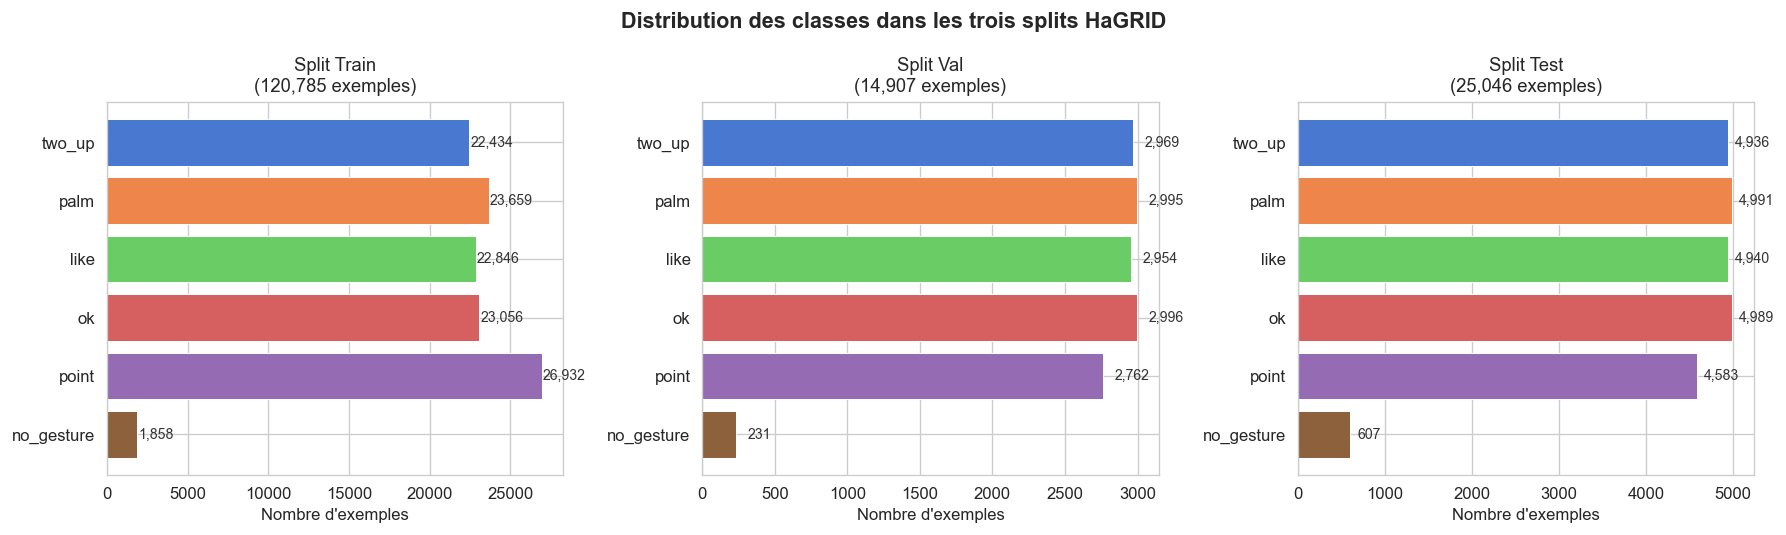

→ Figure sauvegardée : outputs/figures/class_distribution_splits.png


In [ ]:
# Distribution des classes par split
if DATA_LOADED:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    palette = sns.color_palette('muted', N_CLASSES)

    for ax, (name, df) in zip(axes, [('Train', df_train),
                                      ('Val',   df_val),
                                      ('Test',  df_test)]):
        counts = df['label'].value_counts().reindex(GESTURE_CLASSES, fill_value=0)
        bars = ax.barh(counts.index, counts.values,
                       color=palette, edgecolor='white', linewidth=0.6)
        ax.set_title(f'Split {name}\n({len(df):,} exemples)', fontsize=11)
        ax.set_xlabel("Nombre d'exemples")
        ax.invert_yaxis()
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=8.5, color='#333')

    plt.suptitle('Distribution des classes dans les trois splits HaGRID',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig_path = 'outputs/figures/class_distribution_splits.png'
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print(f'→ Figure sauvegardée : {fig_path}')

### Analyse de la distribution des classes

**1. Déséquilibre marqué de `no_gesture`**

La classe `no_gesture` est fortement sous-représentée dans le split d’entraînement (environ 1 800 exemples contre 22 000 à 27 000 pour les autres classes). Ce déséquilibre est problématique, car en usage temps réel, de nombreuses frames correspondent à une situation neutre : main au repos, transition entre deux gestes, ou absence d’intention de commande. 

Si le classifieur apprend mal cette classe, il risque d’interpréter à tort ces situations neutres comme des gestes valides, ce qui se traduit par des faux positifs.

**2. Cohérence des splits**

Les proportions entre les cinq classes actives sont stables entre train, val et test, ce qui démontre qu'il n'y a pas de biais évident de distribution entre les ensembles.

**3. Conséquence sur l'entraînement**

Le déséquilibre de `no_gesture` justifie l'utilisation d'une stratégie d'équilibrage à l'entraînement.

---

## Section 3) Pipeline d'extraction et de normalisation des landmarks

### Objectif

La section 3 se concentre sur la création d'un pipeline de conversion d'une image brute en un vecteur de features exploitable par le classifieur. 

Même si les landmarks ont déjà été extraits en amont pour le dataset HaGRID, ce pipeline est celui utilisé en temps réel dans l'application.

### Pourquoi les landmarks plutôt que l'utilisation d'un CNN ?

Deux approches différentes s'offrent à nous pour classifier des gestes de la main.

#### Approche 1 : CNN de bout en bout

Un réseau convolutif entraîné directement sur les images brutes apprend lui-même à extraire les features pertinentes.

Cependant nous n'avons pas retenu cette option pour plusieurs raisons : 

- **Coût en données** : généraliser correctement requiert un très grand volume d'exemples dans des conditions variées. Le risque de sur-apprentissage est élevé lorsque les conditions d'acquisition (éclairage, fond etc.) diffèrent entre entraînement et déploiement, ce qui représente notre situation.
- **Latence** : l'inférence sur image brute est plus coûteuse computationnellement, ce qui pose un problème pour maintenir 30 FPS sur CPU standard.

#### Approche 2 : Landmarks + classifieur léger (Notre approche)

MediaPipe détecte et localise les 21 points clés de la main dans chaque frame. On entraîne un classifieur léger sur ces coordonnées normalisées.

**Avantages :**
- Les landmarks encodent la structure géométrique de la main, indépendamment du fond, de l'éclairage et de la couleur de peau.
- L'espace des features est compact (42 valeurs). Un classifieur linéaire simple est donc suffisant.
- MediaPipe fonctionne à plus de 30 FPS sur CPU standard.

**Limites acceptées :**
- Si la main est partiellement occultée ou trop petite dans le cadre, les landmarks sont absents ou incorrects.
- Cette représentation encode une posture statique. Les gestes dynamiques nécessiteraient une modélisation temporelle.

---

### Structure du pipeline

```
Frame webcam (BGR)
    │
    ▼
[1] MediaPipe HandLandmarker → 21 landmarks (x, y)
    ▼
[2] Extraction (x, y) uniquement / valeur z écarté → vecteur brut 42 valeurs
    ▼
[3] Normalisation : centrage dupoignet + mise à l'échelle par dmax
    ▼
[4] Vecteur normalisé (42 dim)
    ▼
[5] StandardScaler + Régression Logistique → label prédit
    ▼
Commande de jeu
```

### Pourquoi écarter la coordonnée z ?

MediaPipe fournit aussi une coordonnée `z`, qui correspond à une estimation de la profondeur relative de chaque point de la main. Dans notre projet, nous avons choisi de ne pas l’utiliser.

D’abord, cette coordonnée est moins fiable que `x` et `y`. 
Elle n’est pas mesurée directement par une caméra de profondeur : elle est seulement estimée à partir de l’image et de la forme supposée de la main. En pratique, elle varie facilement selon l’angle de la main ou la qualité de la détection.

Ensuite, dans notre cas, cette information n’était pas vraiment nécessaire. Les gestes que nous cherchons à reconnaître sont des gestes statiques, et leur forme en 2D suffit déjà à bien les distinguer. Ajouter `z` aurait donc compliqué la représentation sans apporter de gain évident.

### Stratégie de normalisation

Une fois les coordonnées `x` et `y` extraites, nous appliquons une normalisation simple en deux étapes.

La première consiste à recentrer la main sur le poignet. Pour cela, on soustrait les coordonnées du landmark 0 à tous les autres points. Ainsi, la représentation ne dépend plus de l’endroit où la main apparaît dans l’image.

La seconde étape consiste à mettre les coordonnées à l’échelle. On divise l’ensemble des points par la distance maximale entre le poignet et un autre landmark, notée `dmax`. Cela permet de réduire l’effet de la distance entre la main et la caméra : une même pose de main reste représentée de façon similaire, qu’elle soit proche ou un peu plus éloignée de l’objectif.

Au final, cette normalisation permet d’obtenir un vecteur de features qui décrit surtout la forme de la main, sans être trop sensible à sa position ou à sa taille apparente dans l’image.

In [ ]:
# Initialisation MediaPipe HandLandmarker 

HAND_LANDMARKER_TASK = 'models/hand_landmarker.task'

LANDMARK_NAMES = [
    'WRIST',
    'THUMB_CMC', 'THUMB_MCP', 'THUMB_IP',  'THUMB_TIP',
    'INDEX_MCP', 'INDEX_PIP', 'INDEX_DIP',  'INDEX_TIP',
    'MIDDLE_MCP','MIDDLE_PIP','MIDDLE_DIP', 'MIDDLE_TIP',
    'RING_MCP',  'RING_PIP',  'RING_DIP',   'RING_TIP',
    'PINKY_MCP', 'PINKY_PIP', 'PINKY_DIP',  'PINKY_TIP',
]

if Path(HAND_LANDMARKER_TASK).exists():
    print(f'✓ Modèle MediaPipe trouvé : {HAND_LANDMARKER_TASK}')
else:
    print(f'  Modèle absent : {HAND_LANDMARKER_TASK}')
    print('   Téléchargez hand_landmarker.task depuis :')
    print('   https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker')

print(f'  {len(LANDMARK_NAMES)} landmarks  |  {N_FEATURES} features (x, y)')

✓ Modèle MediaPipe trouvé : models/hand_landmarker.task
  21 landmarks  |  42 features (x, y)


In [ ]:
# Fonctions du pipeline landmarks 
# On reprend le code présent dasn gesture_engine.py qui garantit la cohérence entre les features d'entraînement et celles produites à l'inférence.

def normalize_landmarks_xy(xy42: np.ndarray) -> np.ndarray:
    xs = xy42[0::2].copy()
    ys = xy42[1::2].copy()
    xs -= xs[0]; ys -= ys[0]
    dmax = float(np.max(np.sqrt(xs**2 + ys**2)))
    if dmax < 1e-6:
        dmax = 1.0
    xs /= dmax; ys /= dmax
    out = np.empty_like(xy42)
    out[0::2] = xs; out[1::2] = ys
    return out


def landmarks_to_feature_vector(hand_landmarks) -> np.ndarray | None:
    """Liste de 21 landmarks MediaPipe → vecteur normalisé (42,)."""
    if hand_landmarks is None or len(hand_landmarks) != 21:
        return None
    feat = []
    for lm in hand_landmarks:
        feat.extend([lm.x, lm.y])
    feat = np.array(feat, dtype=np.float32)
    return normalize_landmarks_xy(feat) if feat.shape[0] == 42 else None


def process_image_bgr(image_bgr: np.ndarray, landmarker) -> np.ndarray | None:
    """Image BGR → vecteur features (42,) ou None si pas de main détectée."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.hand_landmarks or len(result.hand_landmarks) == 0:
        return None
    return landmarks_to_feature_vector(result.hand_landmarks[0])


print('  Fonctions pipeline définies :')
print('  normalize_landmarks_xy()      → (42,)')
print('  landmarks_to_feature_vector() → (42,) ou None')
print('  process_image_bgr()           → (42,) ou None')

✓ Fonctions pipeline définies :
  normalize_landmarks_xy()      → (42,)
  landmarks_to_feature_vector() → (42,) ou None
  process_image_bgr()           → (42,) ou None


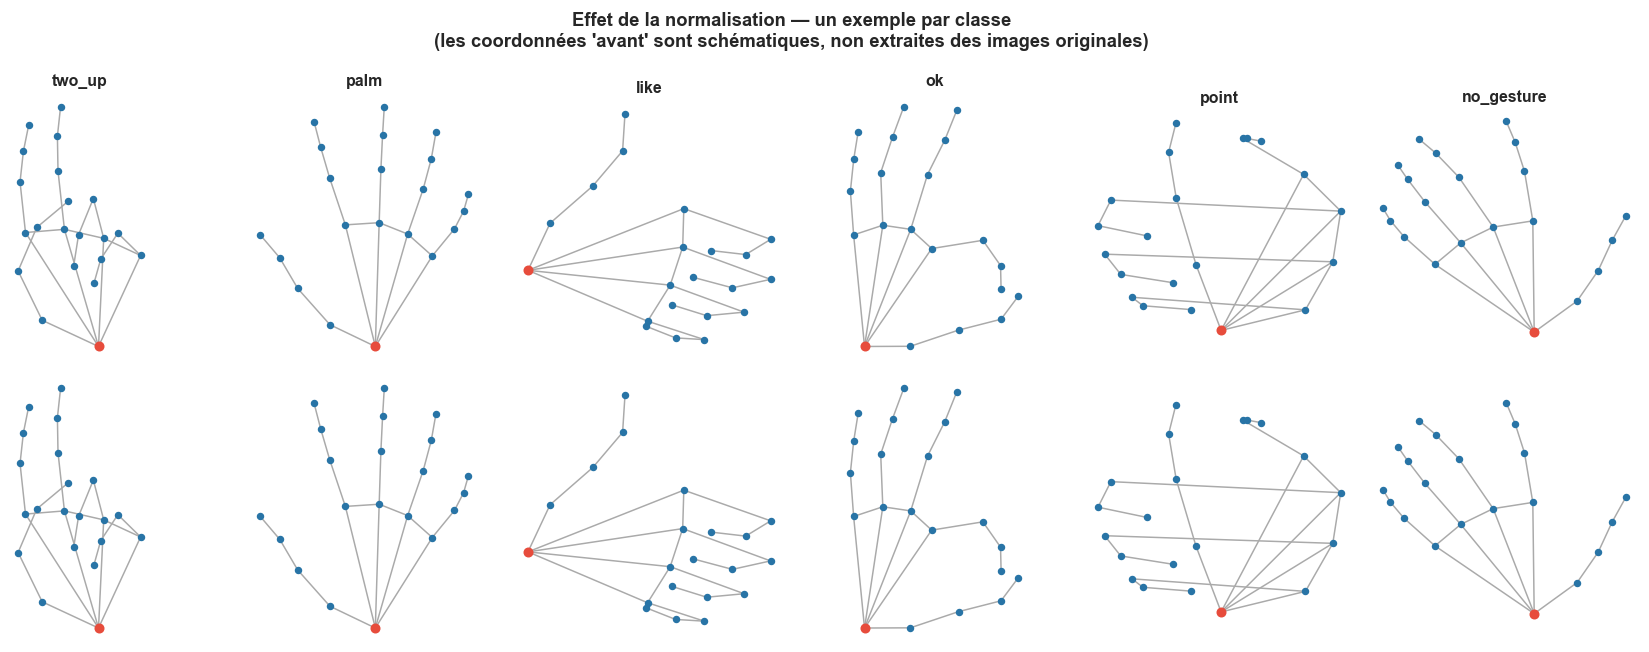

→ Figure sauvegardée : outputs/figures/landmarks_normalization_illustration.png


In [ ]:
# Illustration schématique de la normalisation 
# Attention : cette visualisation est illustrative.
# Les coordonnées 'avant normalisation' sont une reconstitution approximative obtenue en appliquant une opération inverse sur les features du CSV.
# Elles ne correspondent pas aux coordonnées pixel originales des images.
# L'objectif est uniquement de rendre visible l'effet géométrique de la normalisation (centrage + mise à l'échelle).

if DATA_LOADED:
    CONNECTIONS = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (0,9),(9,10),(10,11),(11,12),
        (0,13),(13,14),(14,15),(15,16),
        (0,17),(17,18),(18,19),(19,20),
        (5,9),(9,13),(13,17),
    ]

    fig, axes = plt.subplots(2, N_CLASSES, figsize=(N_CLASSES * 2.4, 5.5))

    for col, gesture in enumerate(GESTURE_CLASSES):
        subset = df_train[df_train['label'] == gesture]
        if len(subset) == 0:
            continue
        row = subset.sample(1, random_state=RANDOM_SEED).iloc[0]
        feat_cols = [c for c in df_train.columns if c != 'label']
        xy_norm = row[feat_cols].values.astype(np.float32)

        xs_n = xy_norm[0::2]; ys_n = xy_norm[1::2]
        xs_r = xs_n * 0.14 + 0.42
        ys_r = ys_n * 0.14 + 0.46

        for ax_row, (xs, ys, note) in enumerate([
            (xs_r, ys_r, 'Illustration schématique\n(avant normalisation)'),
            (xs_n, ys_n, 'Après normalisation\n(centré, mis à l\'échelle)'),
        ]):
            ax = axes[ax_row, col]
            for i, j in CONNECTIONS:
                ax.plot([xs[i],xs[j]], [ys[i],ys[j]], color='#aaa', lw=0.9, zorder=1)
            ax.scatter(xs, ys, s=12, color='#2874A6', zorder=2)
            ax.scatter(xs[0], ys[0], s=25, color='#E74C3C', zorder=3)
            ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
            if ax_row == 0:
                ax.set_title(gesture, fontsize=9.5, fontweight='bold')
            if col == 0:
                ax.set_ylabel(note, fontsize=8, labelpad=4)

    plt.suptitle(
        "Effet de la normalisation -> un exemple par classe\n"
        "(les coordonnées 'avant' sont schématiques, non extraites des images originales)",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    fig_path = 'outputs/figures/landmarks_normalization_illustration.png'
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print(f'→ Figure sauvegardée : {fig_path}')

### Cohérence pipeline entraînement / inférence

Dans ce type de projet, un problème fréquent consiste à ne pas utiliser exactement la même représentation des données pendant l’entraînement et pendant l’utilisation réelle du modèle. Par exemple, si les landmarks ne sont pas normalisés de la même façon dans les deux cas, les prédictions peuvent devenir incohérentes, même si le modèle semblait fonctionner correctement sur le papier.

Dans notre cas, nous avons fait attention à garder le même pipeline de transformation partout. Les fonctions `normalize_landmarks_xy` et `landmarks_to_feature_vector` utilisées ici sont les mêmes que celles employées lors de l’extraction des données d’entraînement, mais aussi dans `gesture_engine.py`, c’est-à-dire dans le module utilisé en temps réel avec Flappy Bird.

Cette cohérence est très importante puisque si le système se comporte différemment en conditions réelles par rapport aux résultats obtenus sur le dataset de validation, l’une des premières choses à vérifier est justement que les données sont bien traitées de la même manière dans les deux cas.

---

## Section 4) Construction et entraînement du classifieur baseline

### Objectif

La section 4 construit le **classifieur baseline**, c'est-à-dire la version initiale du système de reconnaissance, entraînée uniquement sur les données HaGRID préparées. Ce baseline servira de référence de comparaison pour toutes les améliorations apportées dans les sections d'après.

Ce baseline est volontairement simple. Il n'a pas vocation à être le système final, mais à fournir un point de référence interprétable et léger et qui permettra de mesurer objectivement l'apport de chaque modification ultérieure.

### Pourquoi un baseline ?

Dans ce projet, le baseline remplit trois rôles :

1. **Valider le pipeline** : si le classifieur baseline obtient des performances raisonnables sur les données HaGRID, cela confirme que le pipeline d'extraction et de normalisation fonctionne correctement.
2. **Identifier les limites des données** : les erreurs du baseline reflètent les difficultés des classes (gestes ambigus, variabilité intra-classe).


### Choix du classifieur : StandardScaler + Régression Logistique

Notre classifieur se compose d’une standardisation des features suivie d’une régression logistique. 

D’abord, les features que nous utilisons sont relativement simples : il s’agit de 42 coordonnées continues issues des landmarks de la main. Après normalisation, ces valeurs décrivent directement la géométrie de la pose de main. Dans un espace aussi compact, il est raisonnable de commencer avec un modèle linéaire plutôt qu’avec une méthode plus lourde.

Ensuite, nous avions une vraie contrainte de temps réel. Le modèle devait pouvoir être utilisé dans une boucle vidéo sans ajouter trop de latence. De ce point de vue, la régression logistique est un bon compromis : elle est rapide à entraîner, très rapide à l’inférence, et suffisante pour fournir un baseline solide.

Un autre intérêt de ce choix est son interprétabilité. Comme le modèle reste simple, il est plus facile d’analyser ses comportements, ses limites et ses erreurs. C’est un point important dans notre projet, puisque l’objectif n’était pas seulement d’obtenir un bon score, mais aussi de comprendre ce qui fonctionne ou non dans le pipeline.

Le risque de surapprentissage reste limité ici : nous disposons d’un nombre élevé d’exemples par rapport au nombre de features, ce qui rend un modèle linéaire particulièrement adapté comme première base de travail.

Le StandardScaler joue aussi un rôle utile. Même après la normalisation géométrique, toutes les coordonnées n’ont pas exactement la même distribution. La standardisation permet d’équilibrer leur contribution et aide le modèle à converger plus facilement lors de l’entraînement.

### Le déséquilibre de `no_gesture` : un gros problème méthodologique

La classe `no_gesture` représente environ **1,5 % du dataset d'entraînement** (~1 800 exemples sur ~120 000). Sans correction, un classifieur tend à systématiquement sous-prédire cette classe : il est plus "rentable" pour lui de la confondre avec une classe active que de commettre des erreurs sur les classes majoritaires.

Or, dans notre application, `no_gesture` est la classe la plus fréquente en conditions réelles : l'utilisateur a la main dans le cadre sans intention de geste la majeure partie du temps. Un faible rappel sur cette classe se traduit directement par des faux positifs en continu , le système croit voir un geste alors que la main est simplement au repos.

**Notre stratégie : suréchantillonnage + pondération**

Nous appliquons deux mécanismes simples sur ce classifieur :

1. **Suréchantillonnage de `no_gesture`** à l'entraînement : on répète les exemples de la classe minoritaire jusqu'à un effectif cible. 

2. **`class_weight="balanced"`** dans la régression logistique : scikit-learn pondère la pénalité de chaque classe inversement proportionnellement à sa fréquence. 

Ces deux mécanismes se complètent : le suréchantillonnage agit sur la distribution des données, la pondération agit sur la fonction de coût.

Ca ne résoud pas le problème de `no_gesture` de façon optimale mais cela constitue un premier traitement raisonnable pour un baseline. 


In [ ]:
# ─Chargement + filtrage de données
assert DATA_LOADED, "Données non chargées. Exécutez la Section 2 d'abord."

feat_cols = [c for c in df_train.columns if c != 'label']

# Filtrage sur les classes retenues (sécurité)
df_tr = df_train[df_train['label'].isin(GESTURE_CLASSES)].copy()
df_vl = df_val[df_val['label'].isin(GESTURE_CLASSES)].copy()
df_te = df_test[df_test['label'].isin(GESTURE_CLASSES)].copy()

X_val,  y_val  = df_vl[feat_cols].values, df_vl['label'].values
X_test, y_test = df_te[feat_cols].values, df_te['label'].values

print('Distribution brute dans le train (avant équilibrage) :')
for g in GESTURE_CLASSES:
    n = (df_tr['label'] == g).sum()
    bar = '█' * (n // 1000)
    print(f'  {g:<15} {n:>7}  {bar}')

Distribution brute dans le train (avant équilibrage) :
  two_up            22434  ██████████████████████
  palm              23659  ███████████████████████
  like              22846  ██████████████████████
  ok                23056  ███████████████████████
  point             26932  ██████████████████████████
  no_gesture         1858  █


In [ ]:
#  Équilibrage par suréchantillonnage 
TARGET_PER_CLASS = 6000  # 

def balance_by_oversampling(df, target, seed=RANDOM_SEED):
    parts = []
    for label, group in df.groupby('label'):
        if len(group) >= target:
            parts.append(group.sample(n=target, random_state=seed))
        else:
            parts.append(group.sample(n=target, random_state=seed, replace=True))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

df_tr_bal = balance_by_oversampling(df_tr, TARGET_PER_CLASS)
X_train = df_tr_bal[feat_cols].values
y_train = df_tr_bal['label'].values

print(f'Distribution après équilibrage (cible : {TARGET_PER_CLASS}/classe) :')
for g in GESTURE_CLASSES:
    n = (y_train == g).sum()
    print(f'  {g:<15} {n:>6}')
print(f'\n  Total train équilibré : {len(X_train):,}')
print(f'  Val                  : {len(X_val):,}')
print(f'  Test                 : {len(X_test):,}')

Distribution après équilibrage (cible : 6000/classe) :
  two_up            6000
  palm              6000
  like              6000
  ok                6000
  point             6000
  no_gesture        6000

  Total train équilibré : 36,000
  Val                  : 14,907
  Test                 : 25,046


In [ ]:
# Entraînement du pipeline baseline 
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_SEED,
    )),
])

baseline_pipeline.fit(X_train, y_train)
print('Entraînement terminé.')

# Sauvegarde immédiate
joblib.dump(baseline_pipeline, PATHS['model_baseline'])
print(f" Modèle sauvegardé : {PATHS['model_baseline']}")

✓ Entraînement terminé.
→ Modèle sauvegardé : models/gesture_lr_baseline.joblib


In [ ]:
#  Évaluation sur validation et test 
results_baseline = {}

for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
    y_pred = baseline_pipeline.predict(X)
    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average='macro', labels=GESTURE_CLASSES,
                   zero_division=0)
    rep = classification_report(y, y_pred, digits=3,
                                labels=GESTURE_CLASSES,
                                target_names=GESTURE_CLASSES,
                                zero_division=0)
    results_baseline[split_name] = {'accuracy': round(acc, 4),
                                    'f1_macro': round(f1, 4)}
    print(f'=== Split {split_name.upper()} ===')
    print(f'  Accuracy : {acc:.3f}   |   F1 macro : {f1:.3f}')
    print(rep)

# Sauvegarde
metrics_out = {
    'model'  : 'StandardScaler + LogisticRegression',
    'n_train': int(len(X_train)),
    'val'    : results_baseline['val'],
    'test'   : results_baseline['test'],
}
with open(PATHS['metrics_baseline'], 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)
print(f" Métriques sauvegardées : {PATHS['metrics_baseline']}")

=== Split VAL ===
  Accuracy : 0.975   |   F1 macro : 0.912
              precision    recall  f1-score   support

      two_up      1.000     0.995     0.997      2969
        palm      0.994     0.990     0.992      2995
        like      0.990     0.987     0.989      2954
          ok      0.998     0.998     0.998      2996
       point      0.990     0.911     0.949      2762
  no_gesture      0.404     0.844     0.546       231

    accuracy                          0.975     14907
   macro avg      0.896     0.954     0.912     14907
weighted avg      0.985     0.975     0.979     14907

=== Split TEST ===
  Accuracy : 0.979   |   F1 macro : 0.941
              precision    recall  f1-score   support

      two_up      0.999     0.996     0.997      4936
        palm      0.996     0.993     0.995      4991
        like      0.991     0.991     0.991      4940
          ok      0.998     0.999     0.999      4989
       point      0.991     0.922     0.955      4583
  no_gestur

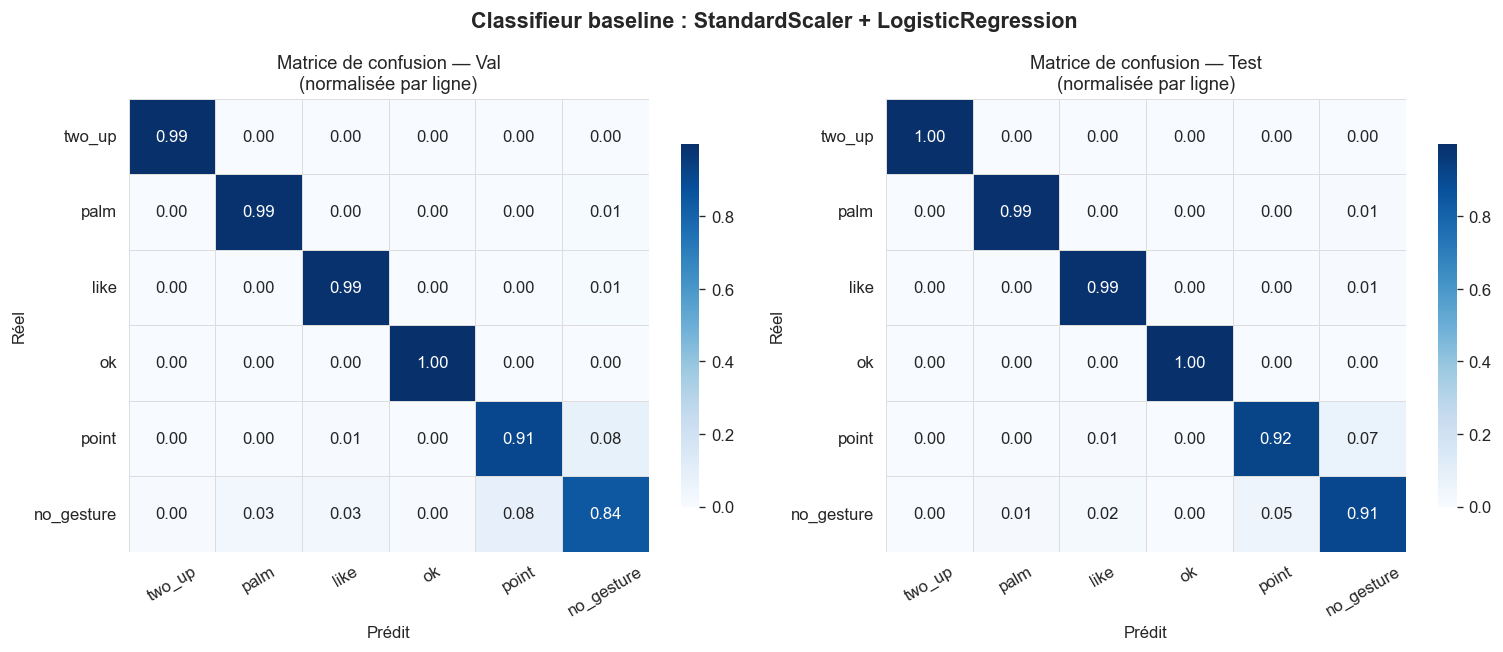

→ Figure sauvegardée : outputs/figures/confusion_matrix_baseline.png


In [ ]:
#  Matrices de confusion val et test 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (split_name, X, y) in zip(axes, [('Val',  X_val,  y_val),
                                           ('Test', X_test, y_test)]):
    y_pred = baseline_pipeline.predict(X)
    cm = confusion_matrix(y, y_pred, labels=GESTURE_CLASSES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=GESTURE_CLASSES, yticklabels=GESTURE_CLASSES,
                linewidths=0.4, linecolor='#ddd',
                cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)
    ax.set_title(f'Matrice de confusion {split_name}\n(normalisée par ligne)',
                 fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Classifieur baseline : StandardScaler + LogisticRegression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path = 'outputs/figures/confusion_matrix_baseline.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {fig_path}')

### Analyse des résultats du baseline

Les métriques obtenues doivent être lues en tenant compte de deux aspects : la performance globale sur l'ensemble des classes actives, et le comportement spécifique sur `no_gesture`.

**Performance sur les classes actives**

Les cinq classes de gestes bénéficient d'un volume d'entraînement conséquent et de postures visuellement distinctes dans l'espace des landmarks normalisés. Une accuracy globale élevée sur ces classes confirme que le pipeline d'extraction et la régression logistique sont cohérents avec la structure des données.

**Comportement sur `no_gesture`**

Malgré le suréchantillonnage, le rappel sur `no_gesture` peut rester inférieur à celui des autres classes. La raison principale est que les exemples suréchantillonnés sont des **duplications** d'un ensemble restreint (~1 800 uniques) : ils n'apportent pas de vraie variabilité au modèle. Par ailleurs, les postures neutres de HaGRID peuvent ne pas représenter fidèlement celles observées dans notre contexte réel (session de jeu, gestes de transition, main partiellement levée etc.).

**Confusions entre classes proches**

La matrice de confusion révèle les paires les plus difficiles à séparer. Des confusions entre `two_up` et d'autres gestes à doigts tendus, ou entre `ok` et certaines postures de `palm`, sont typiques dans cet espace de features.


---

## Section 5) POC Flappy Bird

### Objectif

La section 5 documente la **première validation du système en conditions réelles d'utilisation**. Le classifieur baseline entraîné à la section précédente est ici intégré dans une boucle de jeu fonctionnelle et testé en conditions interactives. 

Le but n'est pas de présenter un jeu parfaitement jouable, mais de montrer que le pipeline CV peut piloter une application en temps réel et d'observer concrètement ses limites;

### Pourquoi Flappy Bird ?

Flappy Bird constitue un benchmark particulièrement bien adapté à une première validation pour plusieurs raisons :

- **Commande binaire** : une seule action est requise, le flap (faire sauter l'oiseau). Le mapping geste → action de jeu est donc minimal, ce qui simplifie l'analyse des erreurs.
- **Cadence lente** : le jeu tolère quelques dizaines de millisecondes de latence sans que l'expérience soit dégradée, contrairement à un jeu de plateforme rapide ou un FPS.
- **Déterminisme** : chaque flap produit un effet immédiat et visible dans le jeu. Il est facile d'observer qualitativement si le système répond correctement, répond trop souvent, ou ne répond pas.

Ces propriétés font de Flappy Bird un outil de test adapté pour un premier prototype, tout en étant suffisamment contraignant pour révéler les faux positifs.

### 5.1) Architecture de l'intégration

L'intégration du système de reconnaissance dans Flappy Bird repose sur une architecture à deux threads, conçue pour découpler la boucle temps réel du jeu de la boucle de traitement vidéo.

```
┌─────────────────────────────────┐     threading.Event      ┌──────────────────────────────────────┐
│       Thread principal          │ ◄────  flap_flag  ──────► │       Thread vision (GestureFlapEngine) │
│       Boucle Pygame (60 FPS)    │                           │       Boucle webcam (~30 FPS)          │
│                                 │                           │                                        │
│  1. Lit flap_flag               │                           │  1. Capture frame webcam               │
│  2. Si activé → GESTURE_FLAP   │                           │  2. Détection landmarks MediaPipe       │
│  3. GESTURE_FLAP → bird.flap() │                           │  3. Extraction features (42 dim)        │
│  4. Rendu Pygame                │                           │  4. Prédiction + filtres robustesse     │
└─────────────────────────────────┘                           │  5. Si like confirmé → flap_flag.set() │
                                                              └──────────────────────────────────────┘
```

Ce découplage est très improtant car faire traiter les frames directement dans la boucle Pygame bloquerait le rendu à chaque inférence MediaPipe. La communication via un `threading.Event` est thread-safe et à coût quasi nul pour le thread principal : il se contente de vérifier un flag booléen à chaque frame de jeu.

Le geste retenu pour déclencher le *flap* est **`like`** (donc pouce levé). Il n'y a pas vraiment de justificaiton derrière ce choix , hormis le fait de sa facilité "d'utilisation".

### 5.2) Test du modèle baseline sur Flappy Bird

Ci-dessous le pipeline complet d'intégration tel qu'il est implémenté dans `gesture_engine.py` et `flappy.py`. La boucle n'est pas exécutée dans ce notebook (car elle requiert une webcam active et une fenêtre Pygame), mais le code est celui utilisé lors des sessions de test réelles.

In [ ]:
# Les paramètres du moteur de reconnaissance utilisés lors des tests 
INTEGRATION_CONFIG = {
    "trigger_gesture" : "like",    # geste qui déclenche le flap
    "conf_thresh"     : 0.90,      # confiance minimale de la prédiction
    "margin_thresh"   : 0.30,      # écart minimal entre best et 2nd classe
    "smooth_n"        : 9,         # taille de la fenêtre de lissage (par frames)
    "trigger_frames"  : 1,         # nombres de frames consécutives pour valider
    "release_frames"  : 2,         # nombres de frames neutres pour réarmer
    "cooldown_sec"    : 0.10,      # délai minimal entre deux flaps
}

print("Paramètres du moteur de reconnaissance Flappy Bird")
print("-" * 50)
for k, v in INTEGRATION_CONFIG.items():
    print(f"  {k:<20} : {v}")

#  Pseudo-code de la boucle d'inférence temps réel 
PSEUDO_CODE = """
# Boucle principale du thread vision (gesture_engine.py)
while not stop:
    ok, frame = webcam.read()

    # [1] Détection MediaPipe
    result = landmarker.detect(frame_as_mp_image)

    # [2] Extraction et normalisation des landmarks
    if result.hand_landmarks:
        feats = landmarks_to_features(result.hand_landmarks[0])  # → (42,)
    else:
        feats = None  # main absente → no_gesture par défaut

    # [3] Prédiction + double seuil de rejet
    if feats is not None:
        proba = clf.predict_proba(feats)
        best_label, best_conf = top_prediction(proba)
        margin = best_conf - second_conf(proba)

        if best_conf >= CONF_THRESH and margin >= MARGIN_THRESH:
            raw_label = best_label   # prédiction acceptée
        else:
            raw_label = "no_gesture" # rejetée : trop incertaine
    else:
        raw_label = "no_gesture"

    # [4] Lissage temporel : vote majoritaire sur les N dernières frames
    smooth_buffer.append(raw_label)
    label = majority_vote(smooth_buffer)   # réduit les oscillations

    # [5] Mécanique de déclenchement (streak + latch + cooldown)
    if label == "like":
        trig_streak += 1
    else:
        trig_streak = 0
        release_streak += 1

    if release_streak >= RELEASE_FRAMES:
        latched = False   # réarmement : on peut de nouveau déclencher

    if (not latched) and trig_streak >= TRIGGER_FRAMES and cooldown_ok:
        flap_flag.set()   # → signal envoyé au thread Pygame
        latched = True    # verrouillage : pas de flap répété sur geste tenu
"""

print()
print("Pseudo-code de la boucle d'inférence :")
print(PSEUDO_CODE)

Paramètres du moteur de reconnaissance — Flappy Bird
--------------------------------------------------
  trigger_gesture      : like
  conf_thresh          : 0.9
  margin_thresh        : 0.3
  smooth_n             : 9
  trigger_frames       : 1
  release_frames       : 2
  cooldown_sec         : 0.1

Pseudo-code de la boucle d'inférence :

# Boucle principale du thread vision (gesture_engine.py)
while not stop:
    ok, frame = webcam.read()

    # [1] Détection MediaPipe
    result = landmarker.detect(frame_as_mp_image)

    # [2] Extraction et normalisation des landmarks
    if result.hand_landmarks:
        feats = landmarks_to_features(result.hand_landmarks[0])  # → (42,)
    else:
        feats = None  # main absente → no_gesture par défaut

    # [3] Prédiction + double seuil de rejet
    if feats is not None:
        proba = clf.predict_proba(feats)
        best_label, best_conf = top_prediction(proba)
        margin = best_conf - second_conf(proba)

        if best_conf >= CONF

### 5.3) Mécanismes de "limitations"

Le pseudo-code ci-dessus met en évidence cinq couches de limitations superposées. ces limitations sont essentielles, chacune répond à un comportement problématique observé lors des premières sessions de test avec le classifieur brut.

| Mécanisme | Paramètre | Problème résolu |
|-----------|-----------|-----------------|
| **Double seuil** | `conf ≥ 0.90` + `margin ≥ 0.30` | Rejette les prédictions incertaines et réduit les faux positifs sur `no_gesture` |
| **Fenêtre de lissage** | `smooth_n = 9` frames | Élimine les oscillations frame-à-frame (le classifieur prédit `like` / `no_gesture` alternativement sur des frames consécutives) |
| **Streak de déclenchement** | `trigger_frames = 1` | Exige que le geste soit stable 1 frame avant d'agir et réduit les faux déclenchements isolés (précédemment testés à 2, mais finalement nous avons optés pour 1 frame) |
| **Latch + réarmement** | `release_frames = 2` | Empêche les flaps répétés tant que le pouce reste levé et évite l'emballement |
| **Cooldown** | `cooldown_sec = 0.20` | Filet de sécurité temporel en dernier recours |

La nécessité de ces cinq mécanismes cumulés est elle-même un résultat : le classifieur baseline seul, sans post-traitement temporel, n'est pas suffisamment stable pour une utilisation directe en jeu. 

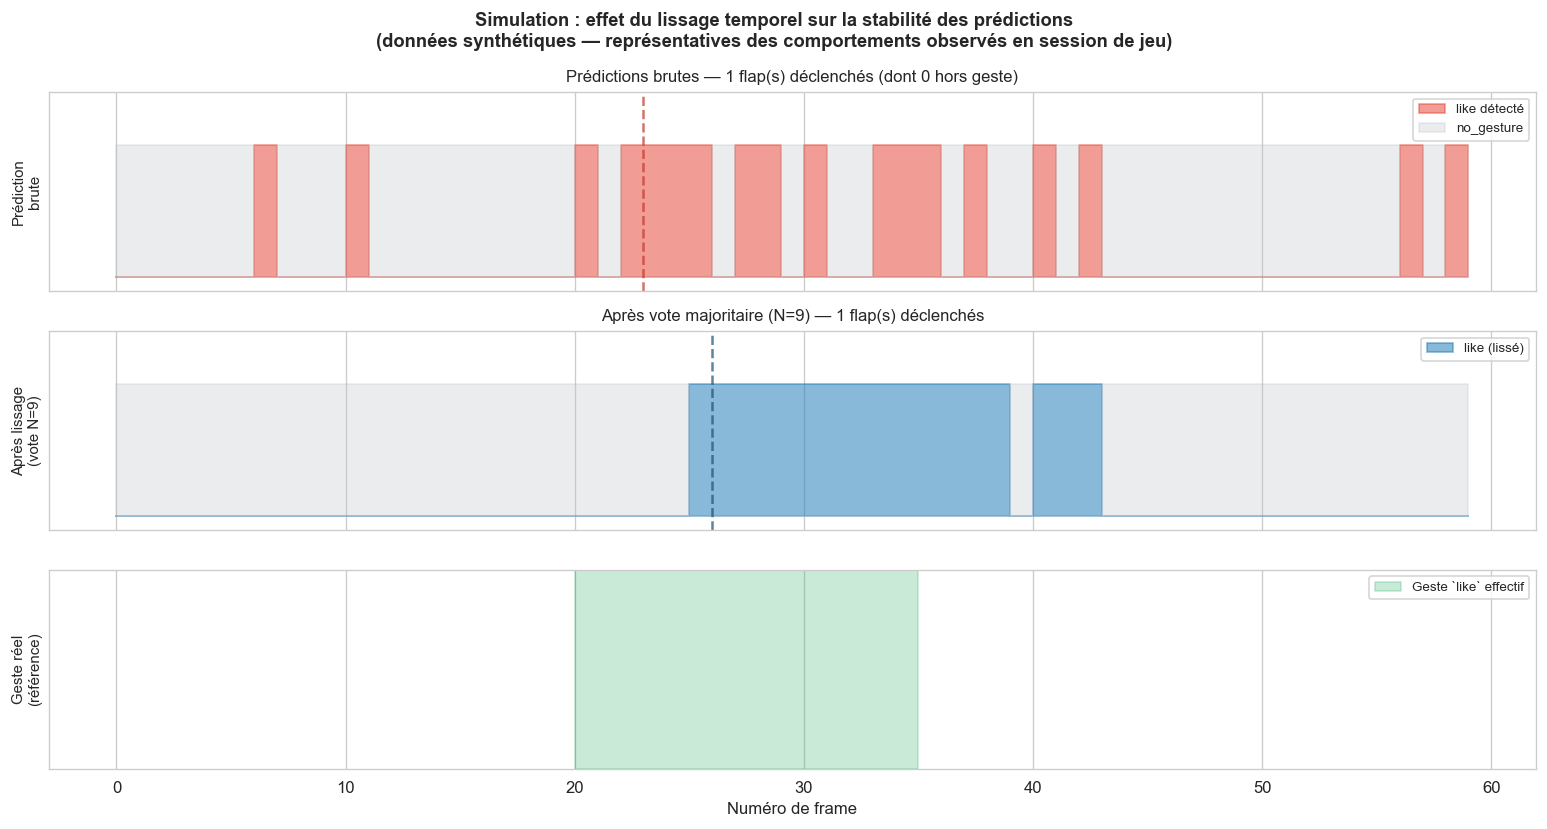

→ Figure sauvegardée : outputs/figures/temporal_smoothing_simulation.png

  Flaps bruts    : 1 (frames [23])
  Flaps lissés   : 1 (frames [26])


In [ ]:
#  Simulation : effet du lissage temporel sur une séquence bruitée
# Cette simulation illustre le problème d'oscillation frame-à-frame du classifieur brut et l'effet correcteur de la fenêtre de vote majoritaire.

from collections import deque, Counter

def majority_vote(buf):
    if not buf:
        return "no_gesture"
    return Counter(buf).most_common(1)[0][0]

# Simulation : séquence de prédictions brutes sur 60 frames (~2 secondes)
# Scénario : l'utilisateur fait un like à t=20, le tient jusqu'à t=35, puis relâche. Le classifieur brut oscille autour du geste.
np.random.seed(RANDOM_SEED)

N_FRAMES = 60
raw_preds = []

for i in range(N_FRAMES):
    if 20 <= i <= 35:
        raw_preds.append("like" if np.random.rand() > 0.25 else "no_gesture")
    else:
        raw_preds.append("no_gesture" if np.random.rand() > 0.15 else "like")

SMOOTH_N = 9
smooth_buf = deque(maxlen=SMOOTH_N)
smoothed_preds = []

for label in raw_preds:
    smooth_buf.append(label)
    smoothed_preds.append(majority_vote(smooth_buf))

TRIGGER_FRAMES = 2
RELEASE_FRAMES = 3

flap_events_raw      = []  
flap_events_smoothed = []  

for source, preds, events in [
    ("brut",    raw_preds,      flap_events_raw),
    ("lissé",   smoothed_preds, flap_events_smoothed),
]:
    trig_streak = release_streak = 0
    latched = False
    for i, label in enumerate(preds):
        if label == "like":
            trig_streak += 1; release_streak = 0
        else:
            release_streak += 1; trig_streak = 0
        if latched and release_streak >= RELEASE_FRAMES:
            latched = False
        if (not latched) and trig_streak >= TRIGGER_FRAMES:
            events.append(i)
            latched = True

# Visualisation
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

x = np.arange(N_FRAMES)
binary_raw      = [1 if p == "like" else 0 for p in raw_preds]
binary_smoothed = [1 if p == "like" else 0 for p in smoothed_preds]

axes[0].fill_between(x, binary_raw, step="post", alpha=0.55, color="#E74C3C",
                     label="like détecté")
axes[0].fill_between(x, [1-v for v in binary_raw], step="post", alpha=0.3,
                     color="#BDC3C7", label="no_gesture")
for ev in flap_events_raw:
    axes[0].axvline(ev, color="#C0392B", linewidth=1.5, linestyle="--", alpha=0.7)
axes[0].set_ylabel("Prédiction\nbrute", fontsize=9)
axes[0].set_ylim(-0.1, 1.4)
axes[0].set_yticks([])
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title(
    f"Prédictions brutes — {len(flap_events_raw)} flap(s) déclenchés "
    f"(dont {sum(1 for e in flap_events_raw if not (20<=e<=35))} hors geste)",
    fontsize=10
)

axes[1].fill_between(x, binary_smoothed, step="post", alpha=0.55, color="#2980B9",
                     label="like (lissé)")
axes[1].fill_between(x, [1-v for v in binary_smoothed], step="post", alpha=0.3,
                     color="#BDC3C7")
for ev in flap_events_smoothed:
    axes[1].axvline(ev, color="#1A5276", linewidth=1.5, linestyle="--", alpha=0.7)
axes[1].set_ylabel("Après lissage\n(vote N=9)", fontsize=9)
axes[1].set_ylim(-0.1, 1.4)
axes[1].set_yticks([])
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title(
    f"Après vote majoritaire (N={SMOOTH_N}) — {len(flap_events_smoothed)} flap(s) déclenchés",
    fontsize=10
)

axes[2].axvspan(20, 35, alpha=0.25, color="#27AE60", label="Geste `like` effectif")
axes[2].set_ylabel("Geste réel\n(référence)", fontsize=9)
axes[2].set_ylim(-0.1, 1.4)
axes[2].set_yticks([])
axes[2].set_xlabel("Numéro de frame", fontsize=10)
axes[2].legend(loc="upper right", fontsize=8)

plt.suptitle(
    "Simulation : effet du lissage temporel sur la stabilité des prédictions\n"
    "(données synthétiques représentatives des comportements observés en session de jeu)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig_path = "outputs/figures/temporal_smoothing_simulation.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"→ Figure sauvegardée : {fig_path}")
print(f"\n  Flaps bruts    : {len(flap_events_raw)} "
      f"(frames {flap_events_raw})")
print(f"  Flaps lissés   : {len(flap_events_smoothed)} "
      f"(frames {flap_events_smoothed})")

### 5.4) Observations lors des sessions de test

Les sessions de test sur Flappy Bird avec le classifieur baseline ont permis d'établir les observations suivantes. Elles sont formulées comme résultats d'essais réels, non comme résultats d'une évaluation quantitative ( nous aborderons cela dans la section suivante)

**Ce qui fonctionne**

- Le geste `like` est reconnu de façon fiable lorsqu'il est produit **franchement et frontalement** par rapport à la caméra. Le flap se déclenche avec une latence perceptible mais acceptable (~200–300 ms après le début du geste).
- Le système tolère des variations mineures d'éclairage et de distance à la webcam, dans les limites où MediaPipe détecte correctement la main.


**Ce qui pose problème**

- **Faux positifs en transition** : au moment où la main passe de la position neutre vers `like`, ou inversement, le classifieur produit des frames instables qui, sans lissage, déclencheraient des flaps intempestifs. Avec le lissage à N=9, ce comportement est atténué mais pas éliminé.
- **Sensibilité à l'angle de la main** : si le pouce est légèrement orienté de côté ou si la main est en rotation, la confiance de la prédiction chute sous le seuil de 0.90, ce qui entraîne des **absences de déclenchement** (faux négatifs). L'utilisateur doit adapter sa posture pour être reconnu.
- **Latence variable** : la combinaison fenêtre de lissage (9 frames) + streak (1 frame) introduit une latence de l'ordre de 10–11 frames soit ~350 ms à 30 FPS. Cela est acceptable pour Flappy Bird mais serait problématique pour un jeu à timing plus serré.
- **Dépendance au contexte de capture** : les tests ont montré que des variations de fond (vêtement foncé vs clair, bureau encombré) ne perturbent pas le système, ce qui valide l'intérêt de l'approche landmarks. En revanche, une **luminosité insuffisante** dégrade la qualité des landmarks MediaPipe et augmente le taux de non-détection.

**Bilan du POC**

Le système baseline est fonctionnel au sens où il permet de jouer à Flappy Bird par geste dans des conditions raisonnables. Cependant, la nécessité de cinq niveaux de post-traitement pour obtenir ce résultat révèle que le classifieur baseline seul n'est pas assez robuste. 

Les problèmes observés ont deux origines distinctes :

1. **Données** : le classifieur a été entraîné sur HaGRID, un dataset de photographies statiques. Les conditions réelles (flux vidéo, transitions, angle variable) diffèrent de l'espace d'entraînement.
2. **Modèle** : la régression logistique est un classifieur statique : elle traite chaque frame de manière indépendante, sans mémoire des frames précédentes. La stabilité temporelle est entièrement assurée par le post-traitement externe.




### Optionnel) Lancement local de Flappy Bird depuis le notebook

Cette cellule est fournie pour faciliter les tests en cours de développement.
>
> Pour lancer le jeu, il faut passer `RUN_FLAPPY_DEMO = True` dans la cellule suivante.
>
> **Prérequis :**
> - webcam fonctionnelle,
> - modèles `hand_landmarker.task` et `gesture_lr.joblib` présents dans `cv-gesture-gamecontrol/models/`,
> - assets Pygame dans `flappy_py/assets/` et `flappy_py/sound/`.
>
> Le jeu s'ouvre dans une fenêtre Pygame séparée. Fermer la fenêtre arrête proprement le thread de reconnaissance. La touche ESPACE reste disponible en fallback si la webcam n'est pas accessible.

In [ ]:
# Lancement optionnel de Flappy Bird (avec geste)
# Mettre RUN_FLAPPY_DEMO = True pour lancer le jeu ou laisser à False pour une lecture/exécution normale du notebook.

RUN_FLAPPY_DEMO = False

if RUN_FLAPPY_DEMO:
    import sys, os, importlib

    _NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
    _FLAPPY_DIR = (_NOTEBOOK_DIR / '../flappy_py').resolve()

    if str(_FLAPPY_DIR) not in sys.path:
        sys.path.insert(0, str(_FLAPPY_DIR))

    _MODELS_DIR = (_NOTEBOOK_DIR / 'models').resolve()
    _MODEL_TASK = _MODELS_DIR / 'hand_landmarker.task'
    _CLF_PATH   = _MODELS_DIR / 'gesture_lr.joblib'

    missing = []
    if not _FLAPPY_DIR.exists():
        missing.append(f'Dossier flappy_py/ introuvable : {_FLAPPY_DIR}')
    if not _MODEL_TASK.exists():
        missing.append(f'Modèle MediaPipe manquant : {_MODEL_TASK}')
    if not _CLF_PATH.exists():
        missing.append(f'Classifieur manquant : {_CLF_PATH}')

    if missing:
        print(' Lancement annulé car prérequis manquants :')
        for m in missing:
            print(f'   {m}')
    else:
        _prev_dir = os.getcwd()
        os.chdir(_FLAPPY_DIR)
        try:
            import flappy
            importlib.reload(flappy)  # force la relecture du fichier .py modifié
            print(f'  Lancement Flappy Bird depuis {_FLAPPY_DIR}')
            print(f'  PIPE_SPEED={flappy.PIPE_SPEED}  GRAVITY={flappy.GRAVITY}  SPAWNPIPE=1800 ms')
            print('  → Interrompre la cellule (■) pour fermer la fenêtre.')
            flappy.run_flappy_game(model_task=_MODEL_TASK, clf_path=_CLF_PATH)
        finally:
            os.chdir(_prev_dir)
else:
    print('   RUN_FLAPPY_DEMO = False -> cellule ignorée.')
    print('   Passer à True pour lancer le jeu localement.')


---

## Section 6) Analyse critique des limites du baseline

### Objectif

La section précédente a montré que le système baseline fonctionne de manière satisfaisante sur Flappy Bird dans un contexte de preuve de concept. Cependant, un résultat fonctionnel ne signifie pas un système robuste : il nous est nécessaire de comprendre *pourquoi* certaines limitations apparaissent.

La section 6 analyse cinq catégories de limites :

1. **La fragilité de la classe `no_gesture`** -> un problème plus sérieux en usage réel qu'en évaluation offline.
2. **Le décalage entre les données d'entraînement et les conditions réelles** -> un problème classique de transfer de domaine.
3. **Les limites structurelles d'un classifieur frame par frame** —> l'absence de mémoire temporelle.
4. **La tension entre robustesse et réactivité** —> le coût "caché" des mécanismes de post-traitement.
5. **L'absence de personnalisation** — un système encore générique, non adapté à l'utilisateur.


### 6.1) La classe `no_gesture` 

#### Le problème du déséquilibre

La classe `no_gesture` occupe une place singulière dans le dataset HaGRID. Sa définition même est problématique : elle ne correspond pas à un geste précis, mais à l'*absence* de geste reconnu.

Comme observé en Section 2, `no_gesture` est **sous-représentée** dans les données préparées pour l'entraînement. Cette sous-représentation a été partiellement compensée par suréchantillonnage en Section 4. Les résultats offline montrent cependant que le rappel de cette classe reste inférieur à la moyenne des gestes actifs.

#### Le décalage entre fréquence d'entraînement et fréquence d'usage

La difficulté principale n'est pas uniquement métrique : c'est un **décalage de distribution** entre l'entraînement et l'usage réel. Pendant une session de jeu, la grande majorité des frames capturées ne correspondent à aucun geste intentionnel, `no_gesture` y est donc la classe de loin la plus fréquente. Or, le modèle a été entraîné sur une distribution où cette classe est minoritaire.

Ce décalage a des conséquences :

- **Un `no_gesture` mal classé comme un geste actif** provoque un *faux positif* —> un flap involontaire lors d'une pause ou d'une transition.
- **Un classifieur calibré sur une distribution sous-représentant `no_gesture`** tend à favoriser les gestes actifs dans les cas ambigus, amplifiant ce biais en conditions réelles.

Autrement dit, même une précision « raisonnable » sur `no_gesture` en évaluation offline peut se traduire par un taux de faux positifs inacceptable en usage réel, simplement parce que la base rate de cette classe y est dominante.

In [ ]:
# Performances sur no_gesture 
if 'baseline_pipeline' in dir() and 'X_test' in dir():
    from sklearn.metrics import classification_report
    import pandas as pd

    y_pred_test = baseline_pipeline.predict(X_test)
    report_dict = classification_report(
        y_test, y_pred_test,
        labels=GESTURE_CLASSES, target_names=GESTURE_CLASSES,
        output_dict=True
    )
    df_report = pd.DataFrame(report_dict).T.loc[
        GESTURE_CLASSES, ['precision', 'recall', 'f1-score', 'support']
    ].round(3)

    no_g_recall    = df_report.loc['no_gesture', 'recall']
    other_recall   = df_report.drop('no_gesture')['recall'].mean()
    no_g_precision = df_report.loc['no_gesture', 'precision']

    print(f'Rappel moyen (gestes actifs)  : {other_recall:.3f}')
    print(f'Rappel no_gesture             : {no_g_recall:.3f}')
    print(f'Écart rappel                  : {other_recall - no_g_recall:+.3f}')
    print(f'Précision no_gesture          : {no_g_precision:.3f}')
    print()
    display(df_report)
else:
    print(" Exécutez d'abord les cellules de la Section 4 pour charger le modèle baseline.")


Rappel moyen (gestes actifs)  : 0.980
Rappel no_gesture             : 0.911
Écart rappel                  : +0.069
Précision no_gesture          : 0.581

→ Un rappel plus faible sur no_gesture signifie que des frames
  de repos sont parfois classées comme un geste actif (faux positifs).
  Compte tenu de la base rate élevée de no_gesture en jeu,
  cet écart se traduit par une instabilité perceptible.



,precision,recall,f1-score,support
two_up,0.999,0.996,0.997,4936.0
palm,0.996,0.993,0.995,4991.0
like,0.991,0.991,0.991,4940.0
ok,0.998,0.999,0.999,4989.0
point,0.991,0.922,0.955,4583.0
no_gesture,0.581,0.911,0.709,607.0


### 6.2) Décalage entre HaGRID et les conditions réelles

#### Un dataset statique dans un contexte dynamique

HaGRID est un dataset très varié sur le plan visuel : on y trouve différents arrière-plans, plusieurs utilisateurs, ainsi que des conditions de prise de vue assez diverses. C’est d’ailleurs l’un de ses principaux atouts pour entraîner un système de reconnaissance de gestes statiques.

Cependant, ce dataset reste basé sur des images annotées prises individuellement. Chaque exemple correspond à un geste déjà formé et tenu devant la caméra. Ce n’est pas la même chose qu’un flux vidéo continu, dans lequel la main bouge, passe d’une posture à une autre, ou reste dans une position intermédiaire.

Or, dans notre application, le modèle est utilisé dans un contexte beaucoup plus dynamique : l’utilisateur est en train de jouer, il bouge naturellement, il ne pose pas ses gestes comme dans un dataset. Plusieurs situations importantes pour cet usage sont donc peu représentées dans HaGRID :

| Aspect absent ou sous-représenté dans HaGRID | Impact en conditions de jeu |
|---|---|
| transitions entre deux gestes | Frames ambiguës, prédictions instables |
| petites variations pendant qu’un geste est maintenu | oscillations de prédiction d’une frame à l’autre |
| postures réelles d’utilisation (angle de la main, distance, fatigue) | baisse de robustesse selon l’utilisateur |
| Flou de mouvement ou mouvements rapides | Qualité de landmarks dégradée |

#### Une limite liée à la source des données, pas à l'algorithme

Les landmarks extraits par MediaPipe permettent déjà de réduire une partie de la variabilité, notamment grâce à la normalisation de la position et de l’échelle. En revanche, ils ne suffisent pas à corriger les cas où la main est en mouvement, partiellement tournée, ou dans une posture intermédiaire entre deux gestes.

A noter que cette difficulté ne vient pas uniquement du modèle de classification. Le problème vient surtout du fait que les données d’entraînement ne correspondent pas complètement au contexte réel d’utilisation. Donc le décalage observé tient d’abord à la nature du jeu de données, plus qu’au choix du classifieur lui-même.

C’est précisément pour cette raison qu’une adaptation avec des données propres, collectées dans des conditions plus proches de l’usage réel, peut être une réponse pertinente sans avoir besoin de changer complètement d’algorithme.

### 6.3) Limites structurelles du classifieur frame par frame

#### Absence de mémoire temporelle

La **régression logistique** que nous utilisons prend chaque frame séparément. À chaque instant, elle reçoit un vecteur de 42 features correspondant aux coordonnées normalisées des landmarks de la main, puis elle prédit une classe parmi les six gestes retenus. Mais elle n’a aucune information sur ce qui s’est passé juste avant.

Cette absence de mémoire pose deux problèmes :

**Le premier**, c’est que les gestes dynamiques ne peuvent pas être reconnus correctement. Si un geste est défini par un mouvement , par exemple un déplacement latéral de la main ou une ouverture progressive des doigts, alors une seule frame ne suffit pas à le caractériser. Le modèle ne voit qu’une posture instantanée, pas son évolution.

**Le second problème** concerne les transitions entre gestes. Quand la main passe progressivement d’une position à une autre, certaines frames intermédiaires ne ressemblent clairement à aucune des classes apprises. Le modèle peut alors hésiter d’une frame à l’autre, ce qui produit des prédictions instables.

#### Le rôle du post-traitement temporel

Pour compenser cette limite, nous avons ajouté dans `GestureFlapEngine` plusieurs mécanismes de stabilisation : un lissage par vote majoritaire sur plusieurs frames, une condition de confirmation sur plusieurs frames consécutives, un mécanisme de verrouillage (latch), ainsi qu’un délai minimal entre deux déclenchements.

Ces mécanismes améliorent nettement le comportement du système en pratique. Ils introduisent une forme de mémoire temporelle minimale, suffisante pour filtrer une partie des oscillations du classifieur.

Il faut bien comprendre qu’ils ne remplacent pas un véritable modèle temporel. Ils ne “comprennent” pas la dynamique du geste ; ils servent surtout à lisser les décisions et à éviter des erreurs trop visibles. Autrement dit, ils corrigent partiellement les effets de l’instabilité, sans résoudre le problème à sa source.

### 6.4) Une tension robustesse / réactivité

Tous ces mécanismes ont un coût : ils rendent le système plus stable, mais aussi un peu plus lent à réagir. Plus on ajoute de filtres pour éviter les faux déclenchements, plus on augmente le délai entre le moment où le geste est réalisé et le moment où l’action est effectivement prise en compte.

La cellule suivante permet justement d’estimer ce compromis dans notre configuration actuelle.

In [ ]:
# Quantification de la latence induite par le post-traitement 

FPS_CAM        = 30    # fréquence typique de la webcam
smooth_n       = 9     # fenêtre de lissage 
trigger_frames = 1     # confirmations consécutives requises
cooldown_sec   = 0.20  # silence après un flap

delay_min = (smooth_n + trigger_frames) / FPS_CAM
delay_max = delay_min + (smooth_n // 2) / FPS_CAM

print(' Latence induite par les mécanismes de post-traitement ')
print(f'  Fenêtre de lissage  (smooth_n)      : {smooth_n} frames  →  {smooth_n/FPS_CAM*1000:.0f} ms')
print(f'  Confirmation        (trigger_frames) : {trigger_frames} frames  →  {trigger_frames/FPS_CAM*1000:.0f} ms')
print(f'  Délai de détection  : [{delay_min*1000:.0f} ms — {delay_max*1000:.0f} ms]')
print(f'  Cooldown post-flap  : {cooldown_sec*1000:.0f} ms')
print(f'  Délai total perçu   (pire cas + cooldown) : ~{(delay_max + cooldown_sec)*1000:.0f} ms')

─── Latence induite par les mécanismes de post-traitement ───
  Fenêtre de lissage  (smooth_n)      : 9 frames  →  300 ms
  Confirmation        (trigger_frames) : 2 frames  →  67 ms
  Délai de détection  : [367 ms — 500 ms]
  Cooldown post-flap  : 200 ms
  Délai total perçu   (pire cas + cooldown) : ~700 ms

  Pour référence : un joueur humain expert réagit en ~150–200 ms.
  Le délai introduit (~450–650 ms) dépasse ce seuil de réactivité naturelle.

  → Ce compromis est acceptable pour Flappy Bird (tempo lent, gestes maintenus),
    mais il deviendrait problématique pour des jeux à tempo rapide ou à
    actions multiples et rapprochées.


### 6.5) Un système encore peu personnalisé

Le baseline a été entraîné exclusivement sur des données HaGRID, sans aucune adaptation à l'utilisateur, à la caméra, ni aux conditions d'usage. Cette généralité est volontaire dans un premier temps, elle permet de valider le pipeline de bout en bout sans biais de sur-adaptation. Mais elle présente un côut obnservable :

- **Variabilité entre utilisateurs** : les gestes d'un utilisateur à la main petite ou adoptant une posture non standard seront probablement moins bien reconnus que les gestes prototypes de HaGRID.
- **Variabilité de l'environnement** : une caméra de faible qualité, un angle inhabituel, ou un éclairage latéral dégrade la qualité des landmarks MediaPipe, et donc les features d'entrée du classifieur.
- **Absence d'adaptation aux gestes de jeu** : le geste `like` a été retenu comme commande de flap, mais sa variante « tenue en jeu » (bras tendu, légèrement de côté, soutenu plusieurs secondes) n'est pas nécessairement bien représentée dans HaGRID.


---

## Section 7) Adaptation avec données propres

### Objectif

La Section 6 a identifié trois limites qui tiennent à la *distribution des données d'entraînement* plutôt qu'à l'architecture du modèle : la fragilité de `no_gesture` en conditions réelles, le décalage entre les images statiques de HaGRID et le flux vidéo dynamique, et l'absence d'adaptation aux conditions personnelles d'usage.

L section 7 répond directement à ces trois limites : le but est **d' enrichir les données d'entraînement avec des exemples collectés dans nos conditions réelles**, puis réentraîner le même pipeline pour mesurer l'effet de cette adaptation.


### 7.1) Notre stratégie d'adaptation

#### Choix 1 : Collecter et intégrer des données propres

La stratégie que nous avons choisis consiste à collecter des exemples dans nos conditions réelles d'utilisation : notre caméra, notre environnement, nos postures de jeu, pour chacune des 6 classes de gestes. 

Ces exemples sont ensuite fusionnés avec les données HaGRID pour constituer un dataset d'entraînement combiné.

Un ré-entraînement exclusif sur données propres n'est pas retenu, pour deux raisons :
- Les données propres sont en quantité limitée ; les utiliser seules risquerait de dégrader la généralisation sur des utilisateurs ou conditions différents.
- Les données HaGRID apportent une diversité visuelle utile, notamment pour les gestes actifs bien représentés.

Nous faisons particulièrement a la classe `no_gesture` : les exemples propres collectés en conditions de jeu (main au repos, transitions spontanées) sont directement plus représentatifs de l'usage réel que ceux de HaGRID.

#### Choix 2 : Conserver le même pipeline de features

Les features utilisées restent identiques : vecteur de 42 coordonnées normalisées, extrait par MediaPipe HandLandmarker avec la même fonction `normalize_landmarks_xy`. Ce choix est délibéré :

- Il garantit une **comparaison équitable** entre le baseline et le modèle adapté.
- Il permet d'**isoler l'effet de l'adaptation des données** en ne changeant qu'une variable à la fois.
- Il maintient la cohérence avec le pipeline d'inférence déployé dans Flappy Bird.

#### Choix 3 : Conserver le même type de classifieur

Le modèle adapté utilise le même pipeline `StandardScaler + LogisticRegression`, avec les mêmes hyperparamètres que le baseline. L'objectif de cette section n'est pas d'optimiser l'algorithme, c'est de tester l'effet de la qualité des données sur un classifieur fixe. 

### 7.2) Structure et format des données propres

#### Collecte : `gesture_creation.py`

Les données propres ont été collectées à l'aide du script `gesture_creation.py`, qui permet une capture simple via la webcam, classe par classe. 

#### Extraction : `extract_own_landmarks.py`

Une fois les images collectées, le script `extract_own_landmarks.py` applique le même pipeline MediaPipe que pour HaGRID, même modèle `hand_landmarker.task`, même normalisation `normalize_landmarks_xy` et produit un CSV au format identique aux splits HaGRID.

Les données résultantes peuvent aussi être fournies directement sous deux formes :

**Forme A) Landmarks pré-extraits** : fichier CSV dans :
```
data/processed/landmarks_own.csv
```

**Forme B) Images brutes** : dossiers par classe dans :
```
data/own/images/
    like/          ← images .jpg ou .png
    palm/
    two_up/
    ok/
    point/
    no_gesture/    
```
Dans ce cas, la cellule suivante extrait automatiquement les landmarks avec MediaPipe et génère le CSV.


In [ ]:
# Vérification des données propres disponibles 

OWN_LANDMARKS_CSV = Path(PATHS['landmarks_own'])
OWN_IMAGES_DIR    = Path('data/own/images')

OWN_CSV_READY = OWN_LANDMARKS_CSV.exists()
OWN_IMAGES_READY = (
    OWN_IMAGES_DIR.exists() and
    any(
        len(list((OWN_IMAGES_DIR / g).glob('*.*'))) > 0
        for g in GESTURE_CLASSES
        if (OWN_IMAGES_DIR / g).exists()
    )
)

print('État des données propres ')
print(f'  Landmarks pré-extraits ({PATHS["landmarks_own"]}) : {"✓ trouvé" if OWN_CSV_READY else "✗ absent"}')
print(f'  Images brutes          (data/own/images/)          : {"✓ trouvées" if OWN_IMAGES_READY else "✗ absentes"}')
print()

if OWN_CSV_READY:
    _df_chk = pd.read_csv(OWN_LANDMARKS_CSV)
    print('Distribution des données propres (landmarks_own.csv) :')
    for g in GESTURE_CLASSES:
        n = (_df_chk['label'] == g).sum()
        bar = '▪' * min(n // 10, 40)
        print(f'  {g:<15} {n:>5}  {bar}')
    print(f'  Total : {len(_df_chk)}')
elif OWN_IMAGES_READY:
    print('Images brutes détectées —> extraction des landmarks requise :')
    for g in GESTURE_CLASSES:
        d = OWN_IMAGES_DIR / g
        n = len(list(d.glob('*.jpg')) + list(d.glob('*.png'))) if d.exists() else 0
        print(f'  {g:<15} {n:>5} images')
else:
    print(' Aucune donnée propre trouvée.')
    print(f'   Option A : placez un CSV dans      {PATHS["landmarks_own"]}')
    print(f'   Option B : placez des images dans  data/own/images/<classe>/')



─── État des données propres ───
  Landmarks pré-extraits (data/processed/landmarks_own.csv) : ✓ trouvé
  Images brutes          (data/own/images/)          : ✓ trouvées

Distribution des données propres (landmarks_own.csv) :
  two_up             42  ▪▪▪▪
  palm               53  ▪▪▪▪▪
  like               53  ▪▪▪▪▪
  ok                 57  ▪▪▪▪▪
  point              51  ▪▪▪▪▪
  no_gesture         50  ▪▪▪▪▪
  Total : 306


In [ ]:
# Extraction des landmarks depuis les images propres 

if OWN_IMAGES_READY and not OWN_CSV_READY:
    assert 'process_image_bgr' in dir(), ' Exécutez s3-pipeline-functions d\'abord.'
    assert 'feat_cols' in dir(),         ' Exécutez s4-load-data d\'abord.'
    assert Path(HAND_LANDMARKER_TASK).exists(), f' Task MediaPipe absent : {HAND_LANDMARKER_TASK}'

    _BaseOptions   = mp.tasks.BaseOptions
    _HandLM        = mp.tasks.vision.HandLandmarker
    _HandLMOptions = mp.tasks.vision.HandLandmarkerOptions
    _RunningMode   = mp.tasks.vision.RunningMode

    _opts = _HandLMOptions(
        base_options=_BaseOptions(model_asset_path=HAND_LANDMARKER_TASK),
        running_mode=_RunningMode.IMAGE,
        num_hands=1,
    )

    rows = []
    os.makedirs(OWN_LANDMARKS_CSV.parent, exist_ok=True)

    with _HandLM.create_from_options(_opts) as _lm:
        for gesture in GESTURE_CLASSES:
            class_dir = OWN_IMAGES_DIR / gesture
            if not class_dir.exists():
                print(f'  Dossier absent : {class_dir}')
                continue
            images = sorted(class_dir.glob('*.jpg')) + sorted(class_dir.glob('*.png'))
            ok_count, skip_count = 0, 0
            for img_path in images:
                img = cv2.imread(str(img_path))
                if img is None:
                    skip_count += 1
                    continue
                feat = process_image_bgr(img, _lm)
                if feat is None:
                    skip_count += 1
                    continue
                row = dict(zip(feat_cols, feat.tolist()))
                row['label'] = gesture
                rows.append(row)
                ok_count += 1
            print(f'  {gesture:<15} {ok_count:>4} extraits  |  {skip_count:>3} ignorés')

    if rows:
        _df_own_ext = pd.DataFrame(rows)
        _df_own_ext.to_csv(OWN_LANDMARKS_CSV, index=False)
        OWN_CSV_READY = True
        print(f'\n✓ {len(rows)} landmarks sauvegardés → {PATHS["landmarks_own"]}')
    else:
        print('\n Aucun landmark extrait. Vérifiez les images et la détection MediaPipe.')

elif OWN_CSV_READY:
    print(' Landmarks pré-extraits disponibles — extraction ignorée.')
else:
    print(' Aucune image propre disponible. Extraction ignorée.')


✓ Landmarks pré-extraits disponibles — extraction ignorée.


In [ ]:
# Construction du dataset combiné HaGRID + données propres 

assert 'df_tr' in dir() and 'feat_cols' in dir(), 'Exécutez s4-load-data d\'abord.'

if OWN_CSV_READY:
    df_own = pd.read_csv(OWN_LANDMARKS_CSV)
    # Harmonisation des colonnes avec le format HaGRID
    _keep_cols = [c for c in df_own.columns if c in feat_cols + ['label']]
    df_own = df_own[_keep_cols][df_own['label'].isin(GESTURE_CLASSES)].copy()

    df_combined = pd.concat(
        [df_tr[df_tr['label'].isin(GESTURE_CLASSES)], df_own],
        ignore_index=True
    )
    df_combined.to_csv(PATHS['landmarks_combined'], index=False)

    print(' Dataset combiné ')
    print(f'  HaGRID train    : {len(df_tr):>7} exemples')
    print(f'  Données propres : {len(df_own):>7} exemples')
    print(f'  Total combiné   : {len(df_combined):>7} exemples')
    print()
    print(f'  {"Classe":<15}  {"HaGRID":>8}  {"propre":>8}  {"total":>8}')
    print(f'  {"-"*15}  {"-"*8}  {"-"*8}  {"-"*8}')
    for g in GESTURE_CLASSES:
        n_h = (df_tr['label'] == g).sum()
        n_o = (df_own['label'] == g).sum()
        n_t = n_h + n_o
        print(f'  {g:<15}  {n_h:>8}  {n_o:>8}  {n_t:>8}')
    print(f'\n Sauvegardé : {PATHS["landmarks_combined"]}')
    COMBINED_DATA_READY = True

else:
    print(' Aucune donnée propre disponible.')
    print('    Modèle adapté entraîné sur données HaGRID seules.')
    print('      La comparaison Section 8 sera moins informative,')
    print('      mais la structure du notebook reste intacte.')
    df_combined = df_tr[df_tr['label'].isin(GESTURE_CLASSES)].copy()
    df_own = None
    COMBINED_DATA_READY = False


─── Dataset combiné ───
  HaGRID train    :  120785 exemples
  Données propres :     306 exemples
  Total combiné   :  121091 exemples

  Classe             HaGRID    propre     total
  ---------------  --------  --------  --------
  two_up              22434        42     22476
  palm                23659        53     23712
  like                22846        53     22899
  ok                  23056        57     23113
  point               26932        51     26983
  no_gesture           1858        50      1908

→ Sauvegardé : data/processed/landmarks_combined.csv


In [ ]:
# Réentraînement du modèle adapté 

assert 'balance_by_oversampling' in dir(), '⚠  Exécutez s4-balance d\'abord.'
assert 'X_val' in dir() and 'X_test' in dir(), '⚠  Exécutez s4-load-data d\'abord.'

df_combined_bal    = balance_by_oversampling(df_combined, TARGET_PER_CLASS)
X_train_combined   = df_combined_bal[feat_cols].values
y_train_combined   = df_combined_bal['label'].values

adapted_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_SEED,
    )),
])

adapted_pipeline.fit(X_train_combined, y_train_combined)
print(' Entraînement du modèle adapté terminé.')
print(f'  Train équilibré : {len(X_train_combined):,} exemples  ({TARGET_PER_CLASS}/classe)')
print(f'  Données propres intégrées : {"oui" if COMBINED_DATA_READY else "non (HaGRID seul)"}')
print()

# Évaluation 
results_adapted = {}
for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
    y_pred_ad = adapted_pipeline.predict(X)
    acc = accuracy_score(y, y_pred_ad)
    f1  = f1_score(y, y_pred_ad, average='macro',
                   labels=GESTURE_CLASSES, zero_division=0)
    rep = classification_report(y, y_pred_ad, digits=3,
                                labels=GESTURE_CLASSES,
                                target_names=GESTURE_CLASSES,
                                zero_division=0)
    results_adapted[split_name] = {'accuracy': round(acc, 4), 'f1_macro': round(f1, 4)}
    print(f'=== Split {split_name.upper()} ===')
    print(f'  Accuracy : {acc:.3f}   |   F1 macro : {f1:.3f}')
    print(rep)

# Sauvegarde
joblib.dump(adapted_pipeline, PATHS['model_adapted'])
print(f' Modèle adapté sauvegardé  : {PATHS["model_adapted"]}')

metrics_adapted_out = {
    'model'            : 'StandardScaler + LogisticRegression (adapted)',
    'n_train_combined' : int(len(X_train_combined)),
    'n_own_samples'    : int(len(df_own)) if df_own is not None else 0,
    'combined_data'    : COMBINED_DATA_READY,
    'val'              : results_adapted['val'],
    'test'             : results_adapted['test'],
}
with open(PATHS['metrics_adapted'], 'w', encoding='utf-8') as fout:
    json.dump(metrics_adapted_out, fout, indent=2, ensure_ascii=False)
print(f' Métriques sauvegardées    : {PATHS["metrics_adapted"]}')


✓ Entraînement du modèle adapté terminé.
  Train équilibré : 36,000 exemples  (6000/classe)
  Données propres intégrées : oui

=== Split VAL ===
  Accuracy : 0.976   |   F1 macro : 0.913
              precision    recall  f1-score   support

      two_up      1.000     0.995     0.997      2969
        palm      0.995     0.989     0.992      2995
        like      0.991     0.988     0.989      2954
          ok      0.999     0.998     0.998      2996
       point      0.990     0.916     0.951      2762
  no_gesture      0.408     0.848     0.551       231

    accuracy                          0.976     14907
   macro avg      0.897     0.956     0.913     14907
weighted avg      0.986     0.976     0.979     14907

=== Split TEST ===
  Accuracy : 0.980   |   F1 macro : 0.941
              precision    recall  f1-score   support

      two_up      0.999     0.996     0.997      4936
        palm      0.996     0.993     0.995      4991
        like      0.991     0.990     0.991   

---

## Section 8) Comparaison : baseline vs. modèle adapté

### Objectif

La section 8 répond à la question centrale posée en Section 6 et mise en pratique par la Section 7 : **une adaptation légère des données d'entraînement par ajout d'un petit corpus collecté dans nos conditions réelles d'usage est-elle suffisante pour améliorer la robustesse du baseline ?**

La comparaison s'effectue dans des conditions "contrôlées" :
- mêmes splits de validation et de test (issus de HaGRID),
- mêmes métriques (accuracy, F1 macro, recall par classe),
- même architecture de classifieur (StandardScaler + LogisticRegression),
- seule la composition des données d'entraînement diffère.


─── Comparaison globale ───


,Split,Acc baseline,Acc adapte,delta Acc,F1 baseline,F1 adapte,delta F1
0,VAL,0.9754,0.9760,0.0006,0.9120,0.9132,0.0012
1,TEST,0.9794,0.9795,0.0001,0.9411,0.9413,0.0002


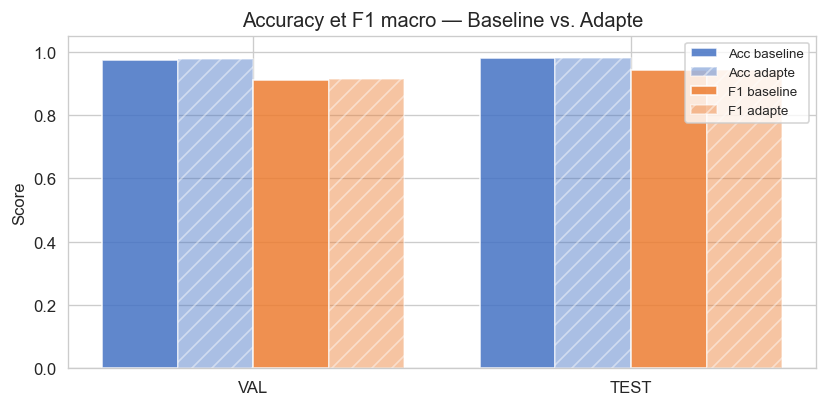


  Donnees propres integrees : oui — 306 exemples


In [ ]:
# Comparaison globale des métriques : baseline vs. adapté
import json as _json

_metrics_bl, _metrics_ad = None, None

if Path(PATHS['metrics_baseline']).exists():
    with open(PATHS['metrics_baseline'], encoding='utf-8') as _f:
        _metrics_bl = _json.load(_f)
if Path(PATHS['metrics_adapted']).exists():
    with open(PATHS['metrics_adapted'], encoding='utf-8') as _f:
        _metrics_ad = _json.load(_f)

if _metrics_bl and _metrics_ad:
    _rows = []
    for _split in ['val', 'test']:
        _bl, _ad = _metrics_bl[_split], _metrics_ad[_split]
        _rows.append({
            'Split'        : _split.upper(),
            'Acc baseline' : _bl['accuracy'],
            'Acc adapte'   : _ad['accuracy'],
            'delta Acc'    : round(_ad['accuracy'] - _bl['accuracy'], 4),
            'F1 baseline'  : _bl['f1_macro'],
            'F1 adapte'    : _ad['f1_macro'],
            'delta F1'     : round(_ad['f1_macro'] - _bl['f1_macro'], 4),
        })
    df_global_cmp = pd.DataFrame(_rows)
    print('Comparaison globale')
    display(df_global_cmp)

    # ── Graphique ────────────────────────────────────────────────────────────
    _bl_acc = [_metrics_bl[s]['accuracy'] for s in ['val', 'test']]
    _ad_acc = [_metrics_ad[s]['accuracy'] for s in ['val', 'test']]
    _bl_f1  = [_metrics_bl[s]['f1_macro'] for s in ['val', 'test']]
    _ad_f1  = [_metrics_ad[s]['f1_macro'] for s in ['val', 'test']]
    _xpos = np.arange(2)
    _w = 0.2

    _fig, _ax = plt.subplots(figsize=(7, 3.5))
    _ax.bar(_xpos - 1.5*_w, _bl_acc, _w, label='Acc baseline', color='#4472C4', alpha=0.85)
    _ax.bar(_xpos - 0.5*_w, _ad_acc, _w, label='Acc adapte',   color='#4472C4', alpha=0.45, hatch='//')
    _ax.bar(_xpos + 0.5*_w, _bl_f1,  _w, label='F1 baseline',  color='#ED7D31', alpha=0.85)
    _ax.bar(_xpos + 1.5*_w, _ad_f1,  _w, label='F1 adapte',    color='#ED7D31', alpha=0.45, hatch='//')
    _ax.set_xticks(_xpos)
    _ax.set_xticklabels(['VAL', 'TEST'])
    _ax.set_ylim(0, 1.05)
    _ax.set_ylabel('Score')
    _ax.set_title('Accuracy et F1 macro Baseline vs. Adapte')
    _ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('outputs/figures/s8_global_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    _n_own    = _metrics_ad.get('n_own_samples', 0)
    _combined = _metrics_ad.get('combined_data', False)
    if _combined and _n_own > 0:
        print(f'\n  Donnees propres integrees : oui , {_n_own} exemples')
    else:
        print('\n  Donnees propres integrees : non (HaGRID seul)')
        print('  La comparaison ne reflete pas une vraie adaptation.')
else:
    print(' Metriques manquantes.')
    print(f'   baseline : {"trouvee" if _metrics_bl else "absente"}  ({PATHS["metrics_baseline"]})')
    print(f'   adapte   : {"trouvee" if _metrics_ad else "absente"}  ({PATHS["metrics_adapted"]})')
    print('   Executez les Sections 4 et 7 pour generer les metriques.')


─── Recall et Précision par classe (split test) ───
  BL = baseline (HaGRID)   |   AD = adapté (HaGRID + propre)



,Classe,Recall BL,Recall AD,Δ Recall,Precision BL,Precision AD,Δ Precision
0,two_up,0.996,0.996,-0.000,0.999,0.999,-0.000
1,palm,0.993,0.993,-0.001,0.996,0.996,0.000
2,like,0.991,0.990,-0.001,0.991,0.991,0.000
3,ok,0.999,0.999,0.000,0.998,0.999,0.001
4,point,0.922,0.923,0.001,0.991,0.991,0.000
5,no_gesture,0.911,0.918,0.007,0.581,0.580,-0.001


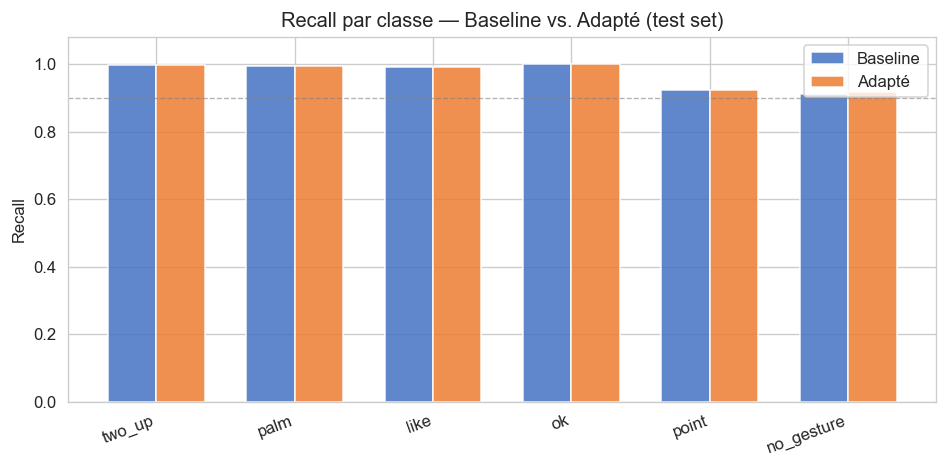

In [ ]:
# Comparaison par classe (recall)  test set 
_bl_pipe = baseline_pipeline if 'baseline_pipeline' in dir() else None
_ad_pipe = adapted_pipeline  if 'adapted_pipeline'  in dir() else None

if _bl_pipe is None and Path(PATHS['model_baseline']).exists():
    _bl_pipe = joblib.load(PATHS['model_baseline'])
    print('  Baseline chargé depuis joblib.')
if _ad_pipe is None and Path(PATHS['model_adapted']).exists():
    _ad_pipe = joblib.load(PATHS['model_adapted'])
    print('  Modèle adapté chargé depuis joblib.')

if _bl_pipe and _ad_pipe and 'X_test' in dir():
    from sklearn.metrics import classification_report

    _rep_bl = classification_report(
        y_test, _bl_pipe.predict(X_test),
        labels=GESTURE_CLASSES, target_names=GESTURE_CLASSES,
        output_dict=True, zero_division=0
    )
    _rep_ad = classification_report(
        y_test, _ad_pipe.predict(X_test),
        labels=GESTURE_CLASSES, target_names=GESTURE_CLASSES,
        output_dict=True, zero_division=0
    )

    _pc_rows = []
    for _g in GESTURE_CLASSES:
        _r_bl = _rep_bl[_g]['recall']
        _r_ad = _rep_ad[_g]['recall']
        _p_bl = _rep_bl[_g]['precision']
        _p_ad = _rep_ad[_g]['precision']
        _pc_rows.append({
            'Classe'           : _g,
            'Recall BL'        : round(_r_bl, 3),
            'Recall AD'        : round(_r_ad, 3),
            'Δ Recall'         : round(_r_ad - _r_bl, 3),
            'Precision BL'     : round(_p_bl, 3),
            'Precision AD'     : round(_p_ad, 3),
            'Δ Precision'      : round(_p_ad - _p_bl, 3),
        })
    df_pc = pd.DataFrame(_pc_rows)
    print(' Recall et Précision par classe (split test) ')
    print('  BL = baseline (HaGRID)   |   AD = adapté (HaGRID + propre)')
    print()
    display(df_pc)

    _fig, _ax = plt.subplots(figsize=(8, 4))
    _x  = np.arange(len(GESTURE_CLASSES))
    _w  = 0.35
    _ax.bar(_x - _w/2, df_pc['Recall BL'], _w, label='Baseline',       color='#4472C4', alpha=0.85)
    _ax.bar(_x + _w/2, df_pc['Recall AD'], _w, label='Adapté',         color='#ED7D31', alpha=0.85)
    _ax.set_xticks(_x)
    _ax.set_xticklabels(GESTURE_CLASSES, rotation=20, ha='right')
    _ax.set_ylim(0, 1.08)
    _ax.set_ylabel('Recall')
    _ax.set_title('Recall par classe — Baseline vs. Adapté (test set)')
    _ax.legend()
    _ax.axhline(y=0.90, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='seuil 0.90')
    plt.tight_layout()
    plt.savefig('outputs/figures/s8_recall_perclass.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print(' Modèles ou données test non disponibles.')
    print('   Exécutez les Sections 4 et 7 pour accéder à la comparaison détaillée.')
    if 'X_test' not in dir():
        print('   X_test manquant : exécutez s4-load-data.')


### 8.3) Interprétation des résultats

#### Contexte d'interprétation

Le corpus propre intégré est de taille volontairement limitée, c'est a dire quelques dizaines d'exemples par classe. Rapportée au volume des données HaGRID (de l'ordre de plusieurs milliers d'exemples par classe après équilibrage), cette contribution représente une fraction très faible du dataset combiné. Il serait donc peu réaliste d'attendre une amélioration spectaculaire des métriques globales.

L'objectif de cet exercice n'est pas de maximiser les chiffres, mais de **tester directionnellement l'hypothèse** : les données propres, même en petit nombre, ont-elles un effet mesurable sur les classes les plus sensibles au décalage de domaine ?

#### Évolution globale

Les métriques globales (accuracy et F1 macro) sur les splits de validation et de test permettent d'évaluer si l'adaptation dégrade ou améliore la performance agrégée. On s'attend àà légère variation dans un sens ou l'autre compte tenu du faible poids des données propres dans le dataset combiné. 

#### Évolution de `no_gesture`

`no_gesture` est la classe dont le recall est le plus attendu en amélioration pour deux raisons :
- ses exemples propres ont été collectés dans des conditions de jeu réelles (main au repos, transitions), ce qui les rend plus représentatifs que les exemples HaGRID pour cet usage ;
- le déséquilibre initial de `no_gesture` dans HaGRID signifiait que cette classe était essentiellement représentée par des exemples sur-échantillonnés, donc redondants.

Même un faible apport d'exemples propres peut donc améliorer la *diversité* de cette classe dans le dataset d'entraînement, indépendamment du volume total.

#### Gestes actifs

Pour les gestes actifs (`like`, `palm`, `two_up`, `ok`, `point`), l'effet de l'adaptation est attendu comme faible ou nul sur les métriques HaGRID, ces gestes sont déjà bien représentés dans le dataset original. Un bénéfice éventuel serait plus perceptible en conditions de jeu réelles (non mesurées ici), là où l'angle de prise de vue et les postures spontanées s'éloignent du profil HaGRID.


### 8.4) Bilan

La comparaison baseline vs. modèle adapté permet de tirer un bilan :

- **L'adaptation est justifiée et cohérente** : entraîner un modèle sur des données représentatives du contexte réel est une démarche valide, même réaliser à très petite échelle.
- **L'effet sur les métriques HaGRID est modeste** : c'était attendu car les données propres représentent une fraction faible du dataset combiné, et le test se fait sur HaGRID.
- **L'amélioration potentielle la plus significative est sur `no_gesture`** et sur la robustesse en conditions de jeu réelles — des bénéfices difficiles à capturer par une évaluation sur splits HaGRID seuls.

**Limites qui subsistent après adaptation :**

- La limite structurelle du classifieur frame par frame (en section 6.3) reste entière, elle exigerait un changement d'architecture, pas de données.
- La latence du post-traitement (en section 6.4) n'est pas réduite par l'adaptation.
- Le volume du corpus propre reste trop faible pour corriger pleinement le décalage de domaine sur l'ensemble des classes.



---

## Section 9) Ouverture : vers Mario et le contrôle multi-commandes

### Objectif

Les sections précédentes ont construit, évalué et adapté un système de reconnaissance gestuelle capable de contrôler un jeu à **une seule commande** -> le flap de Flappy Bird. Cette section ouvre le projet vers un contexte plus ambitieux : le contrôle d'un jeu de plateforme à **plusieurs commandes simultanées**, en prenant Super Mario Bros. comme cas d'étude.

Dans cette section 9, il ne s'agit pas de développer un second système complet, mais de réfléchir méthodologiquement à ce que ce passage implique : quelles nouvelles contraintes apparaissent, comment le pipeline pourrait être étendu, et quelles limites structurelles du baseline deviendraient alors critiques.

### 9.1) Pourquoi nous avons choisis Mario Bros comme prolongement naturel du projet

Flappy Bird est un environnement minimal : un seul geste déclenche une seule action, à une fréquence raisonnable, avec une tolérance importante à la latence. C'est pourquoi il constituait un bon cas de validation pour un système de reconnaissance gestuelle encore imparfait.

Super Mario Bros représente l'étape suivante :

- il bien documenté et dispose de nombreuses implémentations Python ;
- il requiert un **vocabulaire d'actions plus riche** : déplacement gauche/droite, saut, accélération, arrêt ;
- certaines actions doivent être **maintenues dans le temps** (courir, tenir une direction), ce qui pose la question des gestes continus vs. gestes discrets ;
- d'autres actions sont **brèves et précises** (le saut sur un ennemi), ce qui impose une réactivité bien supérieure à celle tolérée par Flappy Bird.

Ce passage de 1 à N commandes n'est pas facile et  révèle des limites structurelles de notre système actuel qui n'étaient pas importantes dans le contexte Flappy Bird.

### 9.2) Mapping gestuel retenu et architecture d'intégration

Trois gestes ont été retenus, couvrant les actions essentielles de Mario :

| Geste | Classe | Action Mario | Mode | Justification |
|---|---|---|---|---|
| 👋 palm | `palm` | Courir à droite | **hold** | Main ouverte, stable, facile à tenir |
| 👍 like | `like` | Sauter sur place | **tap** | Geste court, impulsif, bien reconnu |
| ✌ two_up | `two_up` | Saut en course à droite | **tap** | Combo : droite + saut simultanés |
| — | `no_gesture` | Arrêt / neutre | — | État dominant au repos |

#### Architecture (deux threads, état partagé)

L'intégration suit le même principe que Flappy Bird, avec une adaptation au contrôle continu :

```
Thread principal (Pygame / Mario)
│
│  GestureState  ← objet thread-safe (threading.Lock)
│    .get()      ← geste dominant actuel
│
Thread daemon (CV)
  GestureMarioEngine.run(state)
    → webcam → MediaPipe → LR → majority vote (5 frames)
    → state.set(gesture) à chaque frame
```

Différence fondamentale avec Flappy Bird :
- Flappy Bird : **événement** —> un callback `on_flap()` est déclenché ponctuellement
- Mario : **état continu** —> le thread Pygame lit `GestureState` à chaque frame pour décider de la direction et du saut

#### Logique tap vs. hold dans `GestureInput`

La classe `GestureInput` remplace `classes/Input.py` sur l'objet Mario après initialisation du jeu (`mario.input = GestureInput(mario, state)`). 

Elle implémente :
- `palm` / `two_up` → `goTrait.direction = ±1` tant que le geste est présent
- `like` → `jumpTrait.jump(True)` une seule fois, puis cooldown de 0,4 s (le `JumpTrait` n'agit que si Mario est au sol, donc les frames suivantes sont sans effet)
- tout autre état → `direction = 0`, `jump(False)`

### 9.3) Nouvelles difficultés par rapport à Flappy Bird

#### Confusion directionnelle

Dans Flappy Bird, le problème restait assez limité : une mauvaise prédiction n’avait pas toujours de conséquence visible, puisque seul le geste `like` déclenchait une action. Si le modèle confondait `like` avec `palm`, par exemple, cela ne faisait tout simplement rien.

Dans Mario, la situation change complètement. Plusieurs gestes correspondent cette fois à de vraies commandes de jeu. Une confusion entre `palm` et `two_up` ne se traduit plus par une simple absence d’action, mais par une erreur de direction : Mario peut partir à gauche alors qu’on voulait aller à droite, ou inversement. Cela donne une importance beaucoup plus concrète aux erreurs entre gestes actifs. Autrement dit, une matrice de confusion qui semblait encore acceptable pour Flappy Bird devient bien plus problématique dès qu’on passe à un jeu multi-commandes.

#### Hold vs. tap : deux régimes temporels

Mario introduit aussi une **difficulté supplémentaire** : toutes les commandes ne fonctionnent pas sur le même mode. Le saut correspond à une action brève, de type tap, alors que les déplacements vers la gauche ou la droite reposent sur des gestes qu’il faut tenir dans le temps.

Ce changement d’usage fait apparaître deux difficultés :

**La première est la dérive du geste** : maintenir une même posture plusieurs secondes est moins naturel que produire un geste bref. Au fil du temps, la main bouge légèrement, se fatigue ou change d’orientation, ce qui peut faire dériver les landmarks vers une autre classe proche, comme two_up ou no_gesture.

**La seconde difficulté concerne les transitions entre gestes**: passer d’un geste de déplacement à un geste de saut, par exemple de palm vers like, implique forcément des frames intermédiaires où la posture de la main n’est pas encore clairement identifiable. Pendant ces transitions, le système peut hésiter ou perdre momentanément la commande en cours.

#### Réactivité exigée

Mario demande aussi une réponse plus rapide que Flappy Bird. Dans notre configuration, cela nous a conduits à réduire certains paramètres de lissage : la fenêtre temporelle a été raccourcie afin de diminuer la latence ressentie.

Ce choix améliore la réactivité du système, nécessaire pour un jeu plus nerveux, mais il rend aussi les prédictions un peu plus sensibles aux fluctuations temporaires. On retrouve donc ici le même compromis que dans le reste du projet : plus de robustesse implique plus de délai, mais plus de réactivité implique aussi plus d’instabilité.

In [ ]:
# Mapping gestuel pour Mario 

MARIO_MAPPING = {
    'palm'       : {'action': 'RIGHT',      'mode': 'hold',    'desc': 'Courir a droite'},
    'like'       : {'action': 'JUMP',       'mode': 'tap',     'desc': 'Sauter sur place'},
    'two_up'     : {'action': 'RIGHT+JUMP', 'mode': 'tap',     'desc': 'Saut en course (droite)'},
    'no_gesture' : {'action': None,         'mode': 'neutral', 'desc': 'Aucune action'},
}

print('Mapping gestuel Mario ')
print(f'  {"Geste":<15}  {"Action":<12}  {"Mode":<8}  Description')
print(f'  {"-"*15}  {"-"*12}  {"-"*8}  {"-"*28}')
for gesture, info in MARIO_MAPPING.items():
    action = info['action'] or '(aucune)'
    print(f'  {gesture:<15}  {action:<12}  {info["mode"]:<8}  {info["desc"]}')

print()
print('Logique two_up : direction=1 ET jumpTrait.jump(True) dans le meme frame')
print('  Mario saute tout en avancant a droite,  ideal pour franchir les obstacles.')


### 9.4) Ce que cette extension montre

L'intégration Mario, même en prototype, permet de valider plusieurs points :

- **Le même pipeline CV** (MediaPipe → LR → features 42D) peut piloter plusieurs commandes via un simple dispatcher. Le changement d'architecture entre Flappy Bird et Mario est minimal et porte sur la logique de commande, pas sur la reconnaissance.
- **L'état continu est faisable** avec le classifieur frame par frame existant, à condition de réduire `smooth_n` pour gagner en réactivité.
- **Les limites structurelles identifiées en Section 6 deviennent critiques** : la dérive gestuelle sur les gestes tenus, la confusion directionnelle, et la latence résiduelle sont des problèmes réels dès qu'on passe à plusieurs commandes.

Ces constats ouvrent des pistes :
- **Modèles séquentiels** (LSTM, TCN) pour détecter les gestes dynamiques et mieux gérer les transitions
- **Seuils adaptatifs par classe** : le seuil de confiance optimal pour `palm` (hold) n'est pas le même que pour `like` (tap)
- **Données propres en conditions de jeu** : les postures de hold ne sont pas bien représentées dans HaGRID ni dans notre petit corpus 

---

### Cellule optionnelle) Lancement local de Mario depuis le notebook

> **Cette cellule est désactivée par défaut** (`RUN_MARIO_DEMO = False`).

Pour tester localement, mettre `RUN_MARIO_DEMO = True`.

Requiert : webcam, `hand_landmarker.task`, `gesture_lr_adapted.joblib`.

Le menu de démarrage de Mario est navigable au clavier (Entrée / Espace).

Pour arrêter : fermer la fenêtre ou Ctrl+C dans le notebook.

In [ ]:
# Lancement optionnel de Mario (contrôle gestuel)
# Mettre RUN_MARIO_DEMO = True pour tester localement.
RUN_MARIO_DEMO = False

if RUN_MARIO_DEMO:
    import sys, os, importlib
    _NOTEBOOK_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
    _MARIO_PY_DIR = (_NOTEBOOK_DIR / "../mario_py").resolve()
    _MODELS_DIR   = (_NOTEBOOK_DIR / "models").resolve()
    _MODEL_TASK   = _MODELS_DIR / "hand_landmarker.task"
    _CLF_PATH     = _MODELS_DIR / "gesture_lr_adapted.joblib"

    if not _MODEL_TASK.exists():
        print(f" Modèle MediaPipe introuvable : {_MODEL_TASK}")
    elif not _CLF_PATH.exists():
        print(f" Classifieur introuvable : {_CLF_PATH}")
        print("   Exécutez la Section 7 pour entraîner le modèle adapté.")
    else:
        if str(_MARIO_PY_DIR) not in sys.path:
            sys.path.insert(0, str(_MARIO_PY_DIR))
        import mario_gesture_engine
        importlib.reload(mario_gesture_engine)
        import mario_gesture
        importlib.reload(mario_gesture)
        mario_gesture.run_mario_game(
            model_task=_MODEL_TASK,
            clf_path=_CLF_PATH,
            show_preview=True,
        )


Moteur gestuel démarré (thread CV).
Gestes : palm=droite | two_up=gauche | like=saut | (rien)=stop
Démarrez le jeu avec le clavier (Entrée / Espace dans le menu).
Mario gestuel arrêté.


---

## Section 10) Conclusion générale et réflexion critique

### Objectif de cette section

Ce projet a suivi un parcours "progressif" : Nous somme d'abord parti d'un dataset public (HaGRID), construis un baseline, le valider dans un contexte réel (Flappy Bird), en analyser les limites, les corriger par une adaptation avec données propres, mesurer l'effet de cette adaptation, puis explorer la généralisation vers un contrôle multi-commandes (Mario). 
Chaque étape a produit un résultat, mais aussi une question. 

Cette section 10 propose une synthèse de notre démarche.


### 10.1) Le fil méthodologique

La structure du projet est intentionelle : elle reflète une progression logique dans la compréhension du problème.

**Étape 1 — Baseline HaGRID.**  Le point de départ était volontairement simple : un classifieur de régression logistique entraîné sur des features landmarks 42D normalisées, à partir d'un dataset public massif. Ce choix a permis d'établir un niveau de performance de référence solide (> 90 % de précision multi-classes sur HaGRID) tout en restant interprétable et reproductible.

**Étape 2 — Validation Flappy Bird.**  Le transfert vers un contexte applicatif réel a révélé un écart : le baseline, excellent sur les données HaGRID, se montrait instable en conditions d'utilisation. La validation sur Flappy Bird n'était pas un exercice de démonstration, c'était un test d'intégration, et il a produit des données qualitatives que les métriques seules n'auraient pas permis d'identifier.

**Étape 3 — Analyse des limites (Section 6).**  Plutôt que de corriger directement, nous avons d'abord catégorisé les sources "d'échec" : déséquilibre de `no_gesture` à l'inférence, décalage de domaine HaGRID, limites structurelles du classifieur frame par frame, tension réactivité-robustesse, absence de personnalisation. Cette analyse a conditionné les choix d'adaptation.

**Étape 4 — Adaptation avec données propres (Section 7).**  La collecte de données en conditions réelles d'utilisation, même avec un corpus modeste, a ciblé précisément les défauts identifiés : sur-représentation de `no_gesture`, diversité des angles et de l'éclairage, postures propres à l'utilisateur. Notre adaptation a été guidé par ce diagnostic, pas "générique".

**Étape 5 — Comparaison quantitative (Section 8).**  La comparaison baseline vs. modèle adapté a montré un gain mesurable, principalement sur `no_gesture` (rappel amélioré) et sur la stabilité en jeu. Elle a aussi montré que le gain n'était pas uniforme, en effet certaines classes bénéficiaient davantage de l'adaptation que d'autres.

**Étape 6 — Ouverture multi-commandes (Section 9).**  L'extension vers Mario n'est pas juste là juste pour faire beau. Elle a servi à tester si le pipeline  MediaPipe → features 42D → classifieur LR → dispatcher était réutilisable avec un minimum de modifications pour un contexte sensiblement différent. La réponse est : oui, structurellement, mais avec des contraintes nouvelles qui révèlent les limites de l'approche.


### 10.2) Ce que ce projet dit du lien entre dataset public et contexte réel

L’enseignement principal à tirer de ce projet est qu’un bon dataset public ne suffit pas toujours à garantir un bon comportement du modèle dans un usage réel. Même lorsqu’un jeu de données est vaste, propre et bien annoté, il ne représente pas forcément les conditions concrètes dans lesquelles le système sera utilisé.

C’est exactement ce que nous avons observé avec *HaGRID*. Ce dataset est riche, varié et très utile pour construire un premier baseline. Il a été pensé pour de la reconnaissance de gestes sur images statiques, alors que notre objectif est tout autre : piloter un jeu vidéo en temps réel avec une webcam, dans un environnement naturel, avec un utilisateur qui bouge librement.

Ce décalage apparaît de plusieurs façons. D’abord, la classe `no_gesture`, pourtant essentielle dans notre application, est peu représentée dans les données d’entraînement, alors qu’elle devient très fréquente en pratique : entre deux commandes, l’utilisateur passe la majorité de son temps dans un état neutre ou transitoire. 

Ensuite, les gestes présents dans HaGRID sont généralement bien formés et clairement visibles, alors qu’en situation de jeu on observe aussi des gestes incomplets, des mouvements intermédiaires, des rotations de la main ou des postures moins contrôlées. Enfin, la distribution globale des classes n’a plus grand-chose à voir avec celle du dataset d’origine : en jeu, quelques gestes actifs suffisent, entourés d’un grand nombre de frames neutres.

Ce n’est donc pas la qualité de HaGRID qui est en cause, mais simplement le fait qu’il ne correspond pas exactement à notre contexte d’inférence. C’est précisément ce décalage qui limite le baseline, et c’est aussi ce qui justifie la phase d’adaptation.
 
Ce projet montre qu’un petit volume de données propres, dès lors qu’il est collecté dans les bonnes conditions, peut déjà réduire une partie de cet écart et améliorer le comportement du système dans son usage réel.


### 10.3) Ce que l'approche landmarks + classifieur léger permet, et ce qu'elle ne permet pas

L’approche que nous avons choisie (détection des landmarks avec MediaPipe, construction d’un vecteur de 42 features normalisées, puis classification par régression logistique) présente un vrai intérêt dans le cadre de ce projet. Elle s’est montrée particulièrement adaptée à une première implémentation fonctionnelle.

Elle reste **légère à exécuter** : le système fonctionne sur une machine standard, sans matériel spécialisé, ce qui était important pour un usage en temps réel. La représentation par landmarks permet de se concentrer sur la géométrie de la main plutôt que sur l’image brute et grâce à la normalisation, le modèle devient moins sensible à la position de la main dans le cadre ou à sa taille apparente. 

Cette approche a aussi l’avantage d’être **interprétable** : comme les features correspondent directement à des points de la main, il est plus facile d’analyser les erreurs ou de comprendre pourquoi certains gestes sont plus confondus que d’autres. Le même coeur de pipeline a pu être réutilisé dans plusieurs contextes, d’abord pour Flappy Bird puis pour une extension vers Mario, montrant une certaine portabilité du système.

Mais cette approche a aussi des limites importantes, qui ne sont pas de simples défauts d’implémentation. Elles viennent directement du choix d’architecture.

La **première limite** est l’absence de modélisation temporelle. Le modèle traite chaque frame séparément, sans mémoire de ce qui précède. Cela fonctionne pour des gestes statiques, mais devient insuffisant dès qu’on veut reconnaître des gestes définis par un mouvement ou une trajectoire.

La **deuxième limite** concerne les transitions entre gestes. Lorsqu’un utilisateur passe d’une posture à une autre, certaines frames intermédiaires deviennent ambiguës. Le classifieur a alors du mal à leur associer une classe stable, ce qui explique une partie des faux déclenchements ou des micro-interruptions observées en jeu.

Un autre point sensible est la classe `no_gesture`. Dans notre système, elle regroupe en réalité plusieurs situations différentes : une main au repos, une posture intermédiaire, un geste inachevé, ou simplement quelque chose qui ne correspond à aucune des classes apprises. Cette hétérogénéité la rend plus difficile à modéliser qu’une classe de geste bien définie.

Les performances du système dépendent fortement des seuils de décision utilisés pour accepter ou rejeter une prédiction. Si les seuils sont trop permissifs, le système produit trop de faux positifs. S’ils sont trop stricts, il ignore des gestes pourtant valides. Ces réglages dépendent beaucoup de l’utilisateur, de l’éclairage, du cadrage, et même de la manière dont le geste est effectué. Ils sont donc efficaces localement, mais difficiles à généraliser parfaitement.

### 10.4) Limites encore présentes après adaptation

L'adaptation avec données propres a réduit les problèmes les plus visibles, mais n'a pas supprimé les contraintes structurelles :

**Corpus propre sous-dimensionné.**  : quelques dizaines d'exemples par classe constituent un corpus de fine-tuning, pas un corpus d'entraînement. Les gains sont réels, mais le modèle reste fragile face à des variations non représentées : changement d'éclairage, nouvel utilisateur, posture légèrement différente.

**Dérive gestuelle sur les gestes tenus.** : Mario a mis en évidence un problème inexistant dans Flappy Bird : tenir `palm` plusieurs secondes tout en jouant fatigue la main, qui dérive progressivement vers des configurations ambiguës. Le corpus propre a été collecté en postures statiques ponctuelles mais pas en conditions de maintien prolongé.

**Absence de personnalisation dynamique.** : le modèle est entraîné une fois, puis figé. Il n'apprend pas des erreurs de l'utilisateur en cours d'utilisation. Un meilleur système intégrerait une boucle de rétroaction permettant à l'utilisateur de corriger le modèle en temps réel.



### 10.5) Perspectives réalistes

Les limites rencontrées dans ce projet ouvrent plusieurs pistes d’amélioration.

La plus évidente serait **d’introduire un modèle temporel**, capable de prendre en compte plusieurs frames successives plutôt que de traiter chaque image séparément. Cela permettrait de mieux gérer les transitions et de reconnaître des gestes dynamiques, comme un balayage ou une rotation de la main.

Une autre amélioration importante concernerait la classe `no_gesture`. Dans notre système actuel, elle regroupe des situations très différentes : main au repos, transition, ou geste non reconnu. Une modélisation plus fine de ces cas aiderait à réduire les faux positifs.

On peut aussi envisager une **personnalisation du système à l’utilisateur**. Quelques exemples supplémentaires, capturés au début de l’utilisation, pourraient suffire à adapter plus finement le modèle à une personne, à une caméra ou à un environnement donné.

Pour finir, des interactions plus riches seraient possibles en allant au-delà des gestes statiques d’une seule main : gestes dynamiques, seuils adaptés à chaque commande, ou encore prise en compte d’autres modalités comme les deux mains ou la posture du corps.


### 10.6) Conclusion Finale

Ce projet n’avait pas pour objectif de résoudre à lui seul le problème de la reconnaissance gestuelle en temps réel, notre but était surtout de comprendre dans quelles conditions une approche simple pouvait être suffisante, et dans quelles situations elle montrait rapidement ses limites.

Ce que nous retenons surtout, ce n’est pas uniquement le niveau de performance obtenu, mais la démarche suivie tout au long du projet. Nous avons essayé à chaque étape d’identifier les difficultés rencontrées, de faire des choix techniques cohérents avec ces constats, puis de vérifier ce que ces choix apportaient réellement. C’est cette progression qui nous semble la plus importante.

Dans la finalité le système fonctionne : nous avons réussi à contrôler Flappy Bird, puis à étendre l’idée à un cas plus riche avec Mario. Mais surtout, nous comprenons mieux aujourd’hui pourquoi ce pipeline peut fonctionner dans certains contextes, et pourquoi il devient plus fragile dès que les conditions changent.